## 一、课题背景

在现代供应链管理中，库存管理控制是核心环节。多级供应链（如“工厂-分销中心-零售商”）中往往存在“牛鞭效应”，即下游微小的需求波动会导致上游产生巨大的库存波动。合理的库存决策能够在保证客户服务水平（不缺货）的前提下，极大地降低企业的仓储和运营成本。特别是在需求不确定的随机环境下，如何制定动态的补货策略是一个具有极高研究价值的决策优化问题。

## 二、问题定义

OR-Gym 库的 InvManagement-v1 模拟了一个多级供应链的周期性审查库存系统。网络中包含多个节点（例如零售商、批发商、工厂），每个节点都需要在每个周期决定向其上游节点订购多少货物，以满足其下游节点（或最终客户）的需求。本项目模仿 InvManagement-v1 生成类似问题。

在一个包含 M 个层级的供应链系统中（最下游为零售商），每个周期依次发生 6 个步骤：

- 下达补给订单：

> Stages 0 through M − 1 place replenishment orders to their respective suppliers.
Replenishment orders are filled according to available production capacity and available inventory at the respective suppliers. Lead times between stages include both production times and transportation times.

- 接受补给，库存增加：

> Stages 0 through M − 1 receive incoming inventory replenishment shipments that have
made it down the product pipeline after the associated lead times have passed.

- 满足客户需求：

> Customer demand occurs at stage 0 (the retailer) and is filled according to the available inventory at that stage.

- 处理缺货情况

> One of the following occurs at each stage:

> - (a) Unfulfilled sales and replenishment orders are backlogged at a penalty. Note:
Backlogged sales take priority in the following period.

> - (b) Unfulfilled sales and replenishment orders are lost with a goodwill loss penalty.

- 记录剩余库存并计算持仓成本：

> Surplus inventory is held at each stage at a holding cost.

- 周期末库存清零：

> Any inventory remaining at the end of the last period is lost.

### 1. 决策变量

在每个时间步 $t$，针对供应链上的每个节点 $m$（$m=0$ 代表最下游零售商，$m>0$ 代表上游节点）：

- **订货量 $\hat{R}_t^m$**： 节点 $m$ 在周期 $t$ 向上游节点发送的期望补货量。

### 2. 状态变量

- **现有库存量 $I_t^m$**： 节点 $m$ 在周期 $t$ 期初实际持有的可用库存。
- **在途库存 $T_t^m$**： 节点 $m$ 已经成功下达，但因存在提前期 $L_m$，仍在途尚未到达的货物量。
- **缺货量 $U_t^m$**： 节点 $m$ 未能满足其下游发来的补货请求量（$U_t^m = \hat{R}_t^{m-1} - S_t^m$）。对于零售商（$m=0$），可能转化为累积缺货量 $B_{t}^0$。

### 3. 约束条件

* **产能与库存约束**： 节点 $m$ 实际获批的发货量 $R_t^m$ 受到上游产能 $c^{m+1}$、上游当前库存 $I_t^{m+1}$ 的限制：
  $$R_t^m = \min \left( c^{m+1}, I_t^{m+1}, \hat{R}_t^m \right)$$
* **库存流转守恒**： $t+1$ 时刻的期初库存 $=$ $t$ 时刻的期初库存 $+$ 经过提前期后到达的货物量 $-$ 本期的实际发货量：
  $$I_{t+1}^m = I_t^m + R_{t-L_m}^m - S_t^m$$
* **在途库存守恒**：
  $$T_{t+1}^m = T_t^m - R_{t-L_m}^m + R_t^m$$
* **实际发货量限制**：
  * 对于上游节点（$m>0$），实际发货量即为批准给下游的量：$S_t^m = R_t^{m-1}$
  * 对于零售商（$m=0$），发货量受限于当前总可用库存与客户总需求的极小值：$S_t^0 = \min(I_t^0 + R_{t-L_m}^0, D_t + B_{t-1}^0)$

### 4. 随机扰动因素

* **客户需求量随机**：最下游零售商面临的终端客户本期新需求 $D_t$ 是一个随机变量。

### 5. 优化目标 

在有限的运行周期 $T$ 内，最大化整个供应链系统的折现总利润 $\mathbb{E}[\sum P_t^m]$。
节点 $m$ 单个周期 $t$ 的利润计算由以下几部分组成（带有时间折现因子 $\alpha$）：

* **销售收益**：单价 $\times$ 实际销售发货量 ($p^m S_t^m$)
* **采购成本**：采购单价 $\times$ 实际获批的订货量 ($r^m R_t^m$)
* **缺货惩罚**：单位缺货罚金 $\times$ 未满足的量 ($k^m U_t^m$)
* **仓储成本**：单位库存持有成本 $\times$ 期末结余的库存量 ($h^m I_{t+1}^m$)

目标函数可形式化表示为最大化期望累积收益：

$$\max \mathbb{E} \left[ \sum_{t=1}^{T} \sum_{m=0}^{M} \alpha^t \left( p^m S_t^m - r^m R_t^m - k^m U_t^m - h^m I_{t+1}^m \right) \right]$$

## 三、算例生成

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
# 导入库
import numpy as np
import random
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import itertools
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
import pulp
from stable_baselines3.common.callbacks import BaseCallback
random.seed(42)
np.random.seed(42)

In [2]:
class ExactSupplyChainEnv:
    '''
    仿照 OR-Gym 实现的多级供应链库存管理环境。
    '''
    def __init__(self,num_periods=30):
        self.num_periods = num_periods
        self.current_step = 0
        self.num_stages = 4 # 0:零售商, 1:批发商, 2:分销商, 3:工厂
        
        # 初始库存 (零售商, 批发商, 分销商)
        self.I0 = np.array([100, 100, 200]) 
        
        # 成本
        self.p = 2.0  # 终端零售价
        self.r = np.array([1.5, 1.0, 0.75, 0.5]) # 采购成本
        self.k = np.array([0.10, 0.075, 0.05, 0.025]) # 缺货成本
        self.h = np.array([0.15, 0.10, 0.05]) # 仓储成本 (工厂不计)
        
        self.unit_price = np.append(self.p, self.r[:-1])  # 售价
        self.holding_cost = np.append(self.h, 0)           # 仓储 (工厂=0)
        
        self.c = np.array([100, 90, 80]) # 产能限制
        self.L = np.array([3, 5, 10]) # 提前期
        self.alpha = 0.97 # 折扣因子
        
        self.demand_lambda = 20
        self.backlog = True # 缺货积压
        
        self.max_L = int(np.max(self.L))
        m = self.num_stages
        self.pipeline_length = (m - 1) * (self.max_L + 1)
        # 状态维度 = 库存(m-1) + 在途(m-1)*max_L + 缺货积压(m-1) + 库存位置IP(m-1)
        self.state_dim = (m - 1) * (self.max_L + 2) + (m - 1)
        
        self.reset()

    def reset(self):
        '''
        重置环境
        '''
        self.current_step = 0
        m = self.num_stages
        periods = self.num_periods
        
        self.I = np.zeros((periods + 1, m - 1))  # 各期期初库存
        self.I[0, :] = self.I0.copy()
        
        self.T = np.zeros((periods + 1, m - 1))   # 各期在途库存 
        self.R = np.zeros((periods, m - 1))        # 各期实际补货量
        self.D = np.zeros(periods)                 # 各期客户需求
        self.S = np.zeros((periods, m))            # 各期各级销量
        self.B = np.zeros((periods, m))            # 各期各级缺货积压
        self.LS = np.zeros((periods, m))           # 各期各级损失销售
        self.P = np.zeros(periods)                 # 各期利润
        
        self.action_log = np.zeros((periods, m - 1), dtype=np.int32)
        
        self._update_state()
        return self.state

    def _get_pipeline_order(self, order_time, m):
        """
        返回节点 m 在历史时刻 order_time 实际下达的补货量
        """
        if order_time < 0 or order_time >= self.current_step:
            return 0
        return self.R[order_time, m]

    def _update_state(self):
        m = self.num_stages - 1
        t = self.current_step
        lt_max = self.max_L
        
        # 状态布局: [库存(m) | 在途pipeline(m*max_L) | 缺货积压(m) | 库存位置IP(m)]
        state = np.zeros(m * (lt_max + 2) + m)
        
        if t == 0:
            state[:m] = self.I0
        else:
            state[:m] = self.I[t]
        
        # 在途库存
        if t > 0:
            window = min(t, lt_max)
            # 按提前期对齐：self.R[t-window:t] shape=(window, m)
            pipeline_flat = self.R[t - window:t].flatten()
            state[m * (lt_max - window + 1): m * (lt_max + 1)] += pipeline_flat
        
        # 缺货积压 
        if t > 0:
            state[m * (lt_max + 1): m * (lt_max + 2)] = self.B[t - 1, :m]
        
        # 库存位置 IP = I + T - B
        inventory = state[:m]                                        # I
        transit = self.T[t, :] if t > 0 else np.zeros(m)            # T
        backlog = state[m * (lt_max + 1): m * (lt_max + 2)]         # B
        state[m * (lt_max + 2):] = inventory + transit - backlog     # IP
        
        self.state = state.copy()
    
    def step(self, action):
        '''
        仅当 n - L[i] >= 0 时接收补货。
        '''
        n = self.current_step
        m = self.num_stages
        L = self.L
        
        I = self.I[n, :].copy()  # 期初库存
        T = self.T[n, :].copy()  # 期初在途库存
        c = self.c
        
        # 确定期望订货量
        R = np.maximum(action, 0).astype(int)
        self.action_log[n] = R.copy()
        
        # 上游可用库存 (工厂无限)
        Im1 = np.append(I[1:], np.inf)
        
        # 加上积压的补货订单
        if self.backlog and n >= 1:
            R = R + self.B[n - 1, 1:]
        Rcopy = R.copy()  # 保存约束前的期望请求量
        
        # 产能与库存约束 
        R[R >= c] = c[R >= c]
        R[R >= Im1] = Im1[R >= Im1]
        self.R[n, :] = R
        
        # 接收之前订购的货物 
        RnL = np.zeros(m - 1)
        for i in range(m - 1):
            if n - L[i] >= 0:
                RnL[i] = self.R[n - L[i], i].copy()
                I[i] += RnL[i]  # 到货后更新可用库存
                
        # 客户需求
        D0 = np.random.poisson(self.demand_lambda)
        D = D0
        self.D[n] = D0
        
        # 加上之前的客户积压
        if self.backlog and n >= 1:
            D = D0 + self.B[n - 1, 0].copy()
            
        # 计算各级实际发货量 S
        S0 = min(I[0], D)           # 零售商: min(可用库存, 总需求)
        S = np.append(S0, R)        # 各级: 零售商 + 上游各级
        self.S[n, :] = S
        
        # 更新期末库存与在途库存
        I_next = I - S[:-1]         # 扣除各级发出的货物
        T_next = T - RnL + R        # 在途: 减去到货 + 加上新下单
        self.I[n + 1, :] = I_next
        self.T[n + 1, :] = T_next
        
        # 计算未满足需求
        U = np.append(D, Rcopy) - S
        
        # 缺货积压 vs 损失销售
        if self.backlog:
            self.B[n, :] = U
            self.LS[n, :] = np.zeros(m)
        else:
            self.LS[n, :] = U
            self.B[n, :] = np.zeros(m)
            
        # 计算折现利润 
        II = np.append(I_next, 0)    # 期末库存 (工厂=0)
        RR = np.append(R, S[-1])     # 各级采购量 (含工厂生产)
        
        profit = np.sum(self.unit_price * S - (self.r * RR + self.k * U + self.holding_cost * II))
        discounted_profit = (self.alpha ** n) * profit
        self.P[n] = discounted_profit
        
        self.current_step += 1
        done = self.current_step >= self.num_periods
        
        self._update_state()
        
        info = {
            'demand': D0,         # 本期新需求
            'total_demand': D,    # 总需求(含积压)
            'sales': S,
            'backlog': U,
            'replenishment': R
        }
        
        return self.state, discounted_profit, done, info


In [3]:
def plot_inventory(env):
    '''库存随时间变化的图像'''
    periods = np.arange(env.num_periods)
    plt.figure(figsize=(12, 6))
    plt.plot(periods, env.I[:env.num_periods, 0], label='Retailer(stage 0)', marker='o')
    plt.plot(periods, env.I[:env.num_periods, 1], label='Wholesaler(stage 1)', marker='s')
    plt.plot(periods, env.I[:env.num_periods, 2], label='Distributor(stage 2)', marker='^')
    plt.xlabel("Period")
    plt.ylabel("Inventory")
    plt.legend()
    plt.grid(True)
    plt.show()

## 四、Base Stock 策略

### 1. Base Stock

The base stock policy has been shown to be optimal for capacitated production-inventory
systems under certain conditions and it's one of the valid OR approaches used in practice due to its simplicity.

The requested reorder quantity is given by:
$$
\hat{R}_t^m = \max \left( 0, z^m - \sum_{m'=0}^{m} \left( I_t^{m'} + T_t^{m'} - B_{t-1}^{m'} \right) \right)
$$
where $z^m$ is the base-stock level at stage m and the term in the summation is the current inventory position at the beginning of period t.

In [4]:
def get_inventory(env, m, t):
    """
    计算节点 m 在时间 t 的库存位置：可用库存 + 在途库存 - 缺货积压
    """
    I_m = env.I[t, m]  # 可用库存
    T_m = env.T[t, m]  # 在途库存 
   
    B_m = 0
    if env.backlog and t > 0:
        B_m = env.B[t - 1, m]  # 缺货积压
        
    return I_m + T_m - B_m

In [5]:
def base_stock(env, z):
    """
    根据base stock level z = [z_0, z_1, z_2]，计算本期的发货动作
    """
    t = env.current_step
    action = np.zeros(env.num_stages - 1)
    
    IP = np.zeros(env.num_stages - 1)
    for m in range(env.num_stages - 1):
        IP[m] = get_inventory(env, m, t)
        
    for m in range(env.num_stages - 1):
        sum_IP = np.sum(IP[:m+1]) # 当前节点和所有下游节点
        action[m] = max(0, z[m] - sum_IP) # 根据base stock公式节点m在周期t期望向上游节点发出的补货请求量
        
    return action

In [6]:
def evaluate_z(z, env, episodes=50):
    """
    评估特定 z 值的平均利润。
    """
    if np.any(z < 0):
        return 1e6 
    
    total_rewards = []
    
    outer_np_state = np.random.get_state()    # 保存外部 numpy 随机状态
    outer_py_state = random.getstate()        # 保存外部 Python 随机状态
    
    # 蒙特卡洛模拟（训练集种子：1000+，与测试集种子隔离）
    for ep in range(episodes):
        np.random.seed(1000 + ep)  # 训练集种子，与测试集（2000+）完全隔离
        state = env.reset()
        episode_reward = 0
        done = False
        while not done:
            action = base_stock(env, z)
            next_state, reward, done, info = env.step(action)
            episode_reward += reward
        total_rewards.append(episode_reward)
    
    np.random.set_state(outer_np_state)       # 恢复外部 numpy 随机状态
    random.setstate(outer_py_state)            # 恢复外部 Python 随机状态
    
    avg_reward = np.mean(total_rewards)
    return -avg_reward  


### 2. 初始值设定

基于 Powell's method 的 DFO 算法对初始值较为敏感：
$$
z^m \approx \mu \cdot T_m + 2\sigma\sqrt{T_m}, \quad T_m = \sum_{i=0}^{m} L_i + 1
$$


In [7]:
# 参数估计
env = ExactSupplyChainEnv()
historical_demands = []
for ep in range(3):
    np.random.seed(100 + ep)  
    env.reset()
    done = False
    while not done:
        action = np.array([10, 10, 10])
        _, _, done, info = env.step(action)
        historical_demands.append(info['demand'])

mu_hat = np.mean(historical_demands) # 估算均值
sigma_hat = np.std(historical_demands) # 估算标准差

print(f"基于过去 {len(historical_demands)} 天数据，估算日均需求: {mu_hat:.2f}, 需求标准差: {sigma_hat:.2f}")


基于过去 90 天数据，估算日均需求: 20.14, 需求标准差: 4.66


In [8]:
env = ExactSupplyChainEnv()
env.reset()

factor = 3
L = env.L
z0 = np.zeros(3)
T = np.cumsum(L) + 1  # T[m] = L[0]+...+L[m]+1，各阶段的梯队提前期
for m in range(3):
    z0[m] = mu_hat * T[m] + factor * np.sqrt((sigma_hat ** 2) * T[m])
z0 = np.round(z0)
print(f"初始点 z0: {z0}")


初始点 z0: [109. 223. 444.]


In [9]:
-evaluate_z(z0, env) # 初始点利润

np.float64(-1109.7291094460832)

### 3. 基于 Powell's method 的无导数优化 (Derivative-Free Optimization, DFO)

通常采用 IPA 等基于梯度的下降方法寻找最优解。然而，本模型面临的是离散的泊松随机需求，包含了大量的非线性的 $\max/\min$ 操作，目标函数不光滑且不可微，导致梯度下降法在确定最优步长时使用的基于 Wolfe condition 的线搜索方法失效。

基于 Powell's method 的 DFO 算法不依赖目标函数的解析式或梯度，而是以初始值 $z$ 为起点，通过构建共轭方向在参数空间中进行启发式搜索。

> Since the demand distributions are discrete, Powell’s method is followed by either **rounding** the base stock levels to the nearest integer or performing **a local search** to find the nearest optimal integer solution.

In [9]:
print("-" * 10 + "Base Stock + DFO" + "-" * 10)

# Powell's method
result_DFO = minimize(
    fun=evaluate_z, 
    x0=z0, 
    args=(env, 20), 
    method='Powell',
    options={'xtol': 1.0, 'ftol': 1.0, 'maxiter': 30, 'disp': True}
)

z_DFO_round = np.round(result_DFO.x).astype(int)
best_profit_DFO = -evaluate_z(z_DFO_round, env, episodes=20)  # 在取整点重新评估

print(f"最优z*: 零售商={z_DFO_round[0]}, 批发商={z_DFO_round[1]}, 分销商={z_DFO_round[2]}")
print(f"该策略下 30 天的预期折现总利润: {best_profit_DFO:.2f}")

----------Base Stock + DFO----------
Optimization terminated successfully.
         Current function value: -290.082378
         Iterations: 2
         Function evaluations: 50
最优z*: 零售商=73, 批发商=223, 分销商=480
该策略下 30 天的预期折现总利润: 288.86


In [10]:
offsets = [-1, 0, 1]
neighborhood = list(itertools.product(offsets, repeat=len(z_DFO_round)))

best_z_local = z_DFO_round
best_profit_local = -np.inf

print(f"\nPowell连续解取整点: {z_DFO_round}，开始在 27 个近邻点中枚举搜索...")

for offset in neighborhood:
    z_candidate = z_DFO_round + np.array(offset) 
    z_candidate = np.maximum(z_candidate, 0)
    profit_candidate = -evaluate_z(z_candidate, env, episodes=20)
    if profit_candidate > best_profit_local:
        best_profit_local = profit_candidate
        best_z_local = z_candidate

print(f"最优z*: 零售商={best_z_local[0]}, 批发商={best_z_local[1]}, 分销商={best_z_local[2]}")
print(f"该策略下 30 天的预期折现总利润: {best_profit_local:.2f}")


Powell连续解取整点: [ 73 223 480]，开始在 27 个近邻点中枚举搜索...
最优z*: 零售商=72, 批发商=223, 分销商=481
该策略下 30 天的预期折现总利润: 290.60


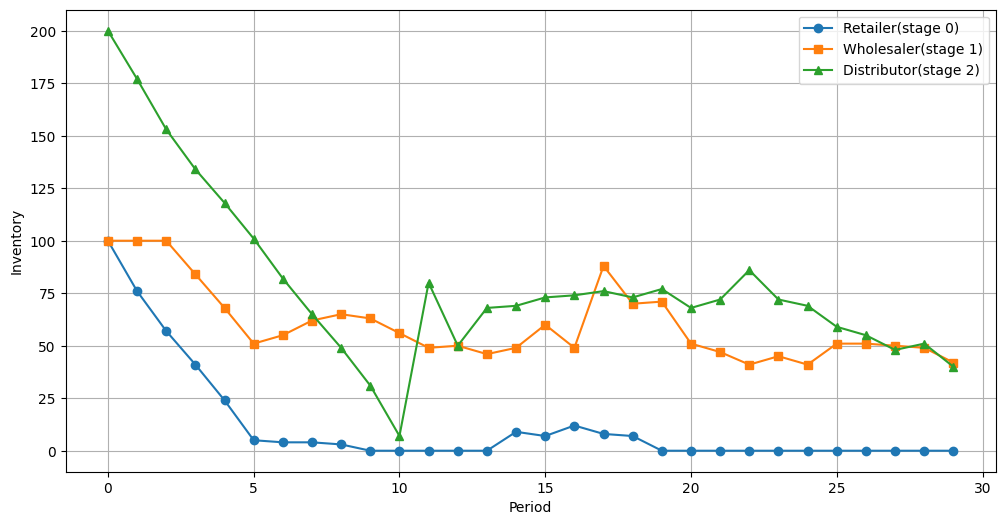

In [12]:
np.random.seed(4237)
env.reset()
done = False
while not done:
    action = base_stock(env, z_DFO_round)
    _, _, done, _ = env.step(action)
plot_inventory(env)

### 4. 基于模拟退火算法的最优参数搜索

In [47]:
def SA(env, z0, T0=1000, rate=0.95, t_min=0.1, iter=50, seed=42):
    """
    模拟退火算法求解最优 Base Stock 参数
    """
    np.random.seed(seed)  
    random.seed(seed)      
    current_z = np.array(z0, dtype=int)
    current_profit = -evaluate_z(current_z, env)  # 转为真实利润    
    best_z = np.copy(current_z)
    best_profit = current_profit
    
    T = T0
    iteration = 0
    history_iterations = []
    history_current_profit = []
    history_best_profit = []
    history_z0 = []
    history_z1 = []
    history_z2 = []
    print(f"初始z: {current_z}, 初始利润: {current_profit:.2f}")
    history_iterations.append(0)
    history_current_profit.append(current_profit)
    history_best_profit.append(current_profit)
    history_z0.append(current_z[0])
    history_z1.append(current_z[1])
    history_z2.append(current_z[2])
    
    while T > t_min:
        for _ in range(iter):
            perturbation = np.random.randint(-5, 6, size=env.num_stages - 1)
            new_z = current_z + perturbation
            new_z = np.maximum(new_z, 0) 
            new_profit = -evaluate_z(new_z, env)  # 真实利润
            delta = new_profit - current_profit
    
            if delta > 0:  
                current_z = new_z
                current_profit = new_profit
                if current_profit > best_profit:
                    best_z = np.copy(current_z)
                    best_profit = current_profit
            else:
                p = np.exp(delta / T) # 接受概率
                if random.random() < p:
                    current_z = new_z
                    current_profit = new_profit
        
        T *= rate # 降温
        iteration += 1

        # 每轮降温后记录一次历史
        history_iterations.append(iteration)
        history_current_profit.append(current_profit)
        history_best_profit.append(best_profit)
        history_z0.append(current_z[0])
        history_z1.append(current_z[1])

        history_z2.append(current_z[2])

        if iteration % 20 == 0:    
            print(f"迭代 {iteration}次 | 当前温度: {T:.1f} | 利润: {current_profit:.2f} | 历史最优利润: {best_profit:.2f}")    

    print(f"最优z*: {best_z}")
    return best_z, best_profit, history_iterations, history_current_profit, history_best_profit, history_z0, history_z1, history_z2

In [48]:
env.reset()
z_SA, profit_SA, sa_iters, sa_cur, sa_best, sa_z0, sa_z1, sa_z2 = SA(env, z0, T0=5000, rate=0.99, t_min=0.1, iter=20)

初始z: [109 223 444], 初始利润: -1109.73
迭代 20次 | 当前温度: 4089.5 | 利润: -1904.93 | 历史最优利润: 59.83
迭代 40次 | 当前温度: 3344.9 | 利润: 49.45 | 历史最优利润: 200.15
迭代 60次 | 当前温度: 2735.8 | 利润: -1024.81 | 历史最优利润: 200.15
迭代 80次 | 当前温度: 2237.6 | 利润: -1069.28 | 历史最优利润: 200.15
迭代 100次 | 当前温度: 1830.2 | 利润: -974.52 | 历史最优利润: 200.15
迭代 120次 | 当前温度: 1496.9 | 利润: 206.24 | 历史最优利润: 255.44
迭代 140次 | 当前温度: 1224.3 | 利润: 127.45 | 历史最优利润: 255.85
迭代 160次 | 当前温度: 1001.4 | 利润: 120.52 | 历史最优利润: 255.85
迭代 180次 | 当前温度: 819.0 | 利润: 149.66 | 历史最优利润: 279.74
迭代 200次 | 当前温度: 669.9 | 利润: 282.18 | 历史最优利润: 308.69
迭代 220次 | 当前温度: 547.9 | 利润: 289.06 | 历史最优利润: 312.73
迭代 240次 | 当前温度: 448.1 | 利润: 217.05 | 历史最优利润: 312.73
迭代 260次 | 当前温度: 366.5 | 利润: 176.15 | 历史最优利润: 312.73
迭代 280次 | 当前温度: 299.8 | 利润: 85.46 | 历史最优利润: 312.73
迭代 300次 | 当前温度: 245.2 | 利润: 3.26 | 历史最优利润: 312.73
迭代 320次 | 当前温度: 200.6 | 利润: 122.09 | 历史最优利润: 312.73
迭代 340次 | 当前温度: 164.0 | 利润: 147.84 | 历史最优利润: 312.73
迭代 360次 | 当前温度: 134.2 | 利润: 95.16 | 历史最优利润: 312.73
迭代 380次 | 当前温度: 109.7 | 

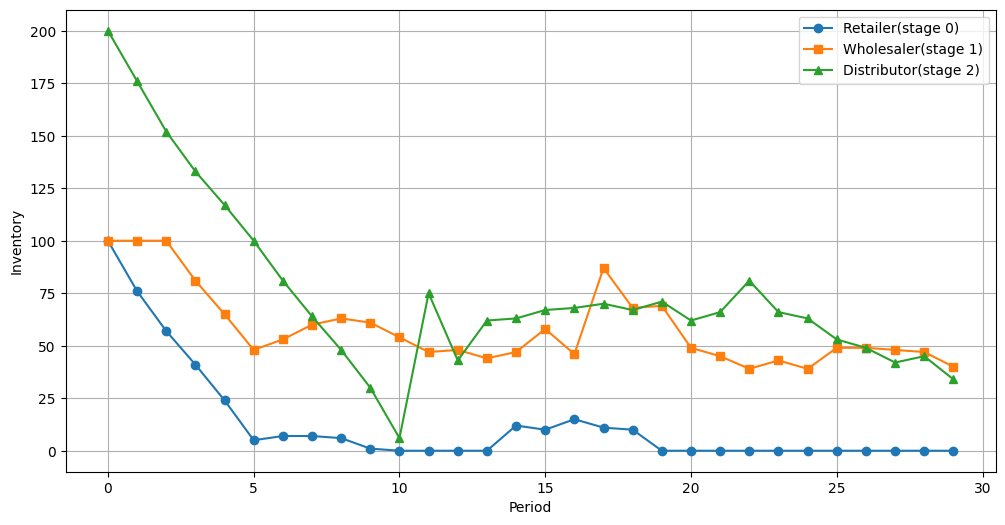

In [11]:
np.random.seed(4237)
z_SA = [76, 224, 475] # 模拟退火耗时较长，直接输入上次搜索到的参数
env.reset()
done = False
while not done:
    action = base_stock(env, z_SA)
    _, _, done, _ = env.step(action)
plot_inventory(env)

In [50]:
def plot_SA(history_iterations, history_current_profit, history_best_profit, history_z0, history_z1, history_z2):
    # 绘制模拟退火过程中利润和 z 值的变化趋势
    plt.figure(figsize=(10, 5))
    plt.plot(history_iterations, history_current_profit, label='Profit', color='blue', alpha=0.8, linewidth=1.1)
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel("Profit", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show() 

    plt.figure(figsize=(10, 5))
    plt.plot(history_iterations, history_z0, label='Retailer(z0)', color='blue')
    plt.plot(history_iterations, history_z1, label='Wholesaler(z1)', color='green')
    plt.plot(history_iterations, history_z2, label='Distributor(z2)', color='orange')
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel(r"$z^m$", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show() 

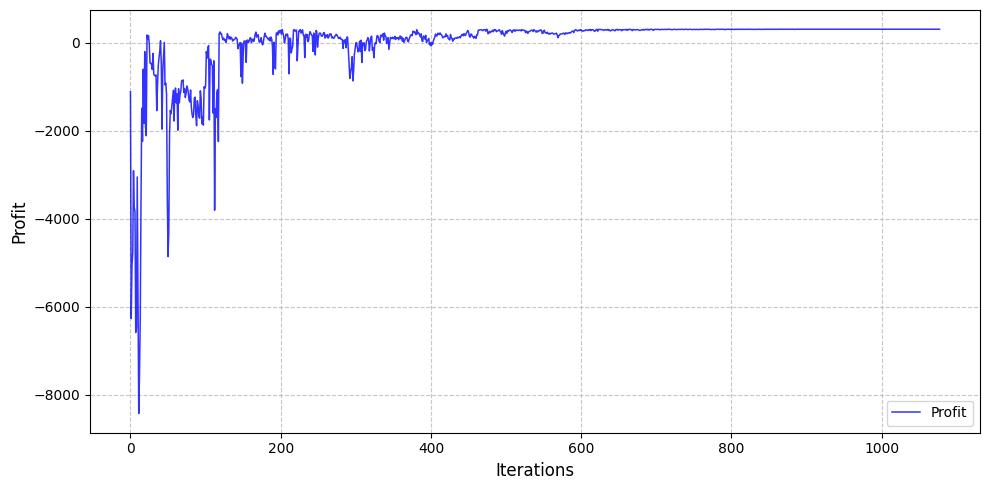

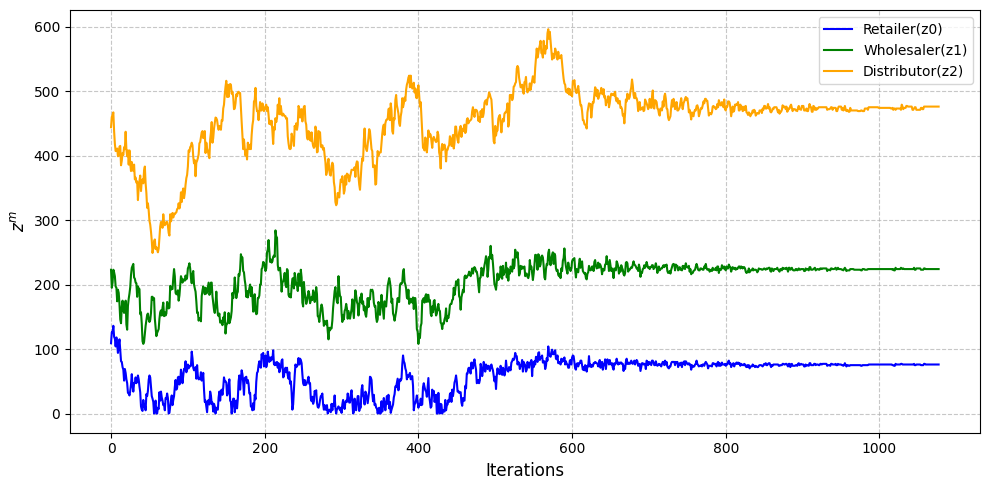

In [51]:
plot_SA(sa_iters, sa_cur, sa_best, sa_z0, sa_z1, sa_z2)

## 五、Shrinking Horizon Linear Programming（SHLP）算法

- 在当前的每一个时间步，假设未来所有的随机需求都等于其数学期望值。
>This approach requires **prior knowledge** of the demand probability distribution and assumes the expected value of the demand for all time periods

- 针对剩余的 Shrinking horizon 建立并求解一个最大化总折现利润的全局 LP 问题。

- 求解完成后，**仅提取并执行第一步的最佳订货决策**。所有未来的决策将被舍弃。
- 时间推进，环境状态更新后，重复上述求解过程。

In [12]:
def SHLP(env, mu_hat):
    """
    根据当前系统状态，以未来需求等于期望值为假设，求解当前步最优动作
    """
    t_current = env.current_step
    N = env.num_periods - t_current  # 剩余的时间

    if N <= 0:
        return np.zeros(env.num_stages - 1)

    M = env.num_stages - 1
    #expected_demand = env.demand_lambda  
    expected_demand = mu_hat  # 假定未来需求均为期望值

    # 创建最大化线性规划问题
    model = pulp.LpProblem(f"SHLP_Step_{t_current}", pulp.LpMaximize)

    # 定义未来 N 个周期的连续决策变量 (tau 代表相对时间步: 0 到 N-1)
    R       = pulp.LpVariable.dicts("R",       ((tau, m) for tau in range(N)   for m in range(M)), lowBound=0)
    I_start = pulp.LpVariable.dicts("I_start", ((tau, m) for tau in range(N+1) for m in range(M)), lowBound=0)
    I_avail = pulp.LpVariable.dicts("I_avail", ((tau, m) for tau in range(N)   for m in range(M)), lowBound=0)
    S       = pulp.LpVariable.dicts("S",       ((tau, m) for tau in range(N)   for m in range(M)), lowBound=0)
    B       = pulp.LpVariable.dicts("B",       ((tau, m) for tau in range(N)   for m in range(M)), lowBound=0)

    # 当前环境的期初库存 (tau = 0)
    for m in range(M):
        model += I_start[0, m] == env.I[t_current, m]

    def get_arrival(tau, m):
        """处理在途库存的到达逻辑"""
        actual_order_time = t_current + tau - env.L[m]
        if actual_order_time < t_current:
            # 订单在过去下达，从环境真实历史中读取
            return env._get_pipeline_order(actual_order_time, m)
        elif tau - env.L[m] < 0:
            # 还在规划窗口之前，尚未下单，到货为0
            return 0
        else:
            # 订单在规划窗口内下达
            return R[tau - env.L[m], m]

    # 线性约束
    for tau in range(N):
        D_tau = expected_demand  # 需求=期望值

        # 缺货积压
        if tau == 0:
            B_prev = env.B[t_current - 1, 0] if env.backlog and t_current > 0 else 0
        else:
            B_prev = B[tau - 1, 0]

        for m in range(M):
            model += I_avail[tau, m] == I_start[tau, m] + get_arrival(tau, m)
            model += R[tau, m] <= env.c[m]  # 产能限制

        for m in range(M - 1):
            model += R[tau, m] <= I_start[tau, m + 1]  # 不超过上游期初库存（到货前），与env.step一致

        # 零售商端销售与积压
        model += S[tau, 0] <= I_avail[tau, 0]
        model += S[tau, 0] <= D_tau + B_prev
        model += B[tau, 0] == D_tau + B_prev - S[tau, 0]

        # 上游节点销售 = 下游实际补货量
        for m in range(1, M):
            model += S[tau, m] == R[tau, m - 1]
            model += B[tau, m] == 0

        # 周期末库存
        for m in range(M):
            model += I_start[tau + 1, m] == I_avail[tau, m] - S[tau, m]

    # 总折现利润目标函数
    total_profit = 0
    for tau in range(N):
        discount = env.alpha ** (t_current + tau)

        # 销售收入：零售商 + 上游各级
        revenue = env.unit_price[0] * S[tau, 0]
        for m in range(M):
            revenue += env.unit_price[m + 1] * R[tau, m]

        # 采购/生产成本：env.r[m] 对应节点 m 的采购成本
        proc_cost = pulp.lpSum(env.r[m] * R[tau, m] for m in range(M))
        proc_cost += env.r[M] * R[tau, M - 1]  # 工厂生产成本

        # 缺货惩罚：env.k[m]
        penalty = pulp.lpSum(env.k[m] * B[tau, m] for m in range(M))

        # 仓储成本：env.holding_cost[m]
        holding = pulp.lpSum(env.holding_cost[m] * I_start[tau + 1, m] for m in range(M))

        total_profit += discount * (revenue - proc_cost - penalty - holding)

    model += total_profit

    # 求解，仅提取规划序列中第一步的动作
    model.solve(pulp.PULP_CBC_CMD(msg=False))

    action = np.zeros(M)
    if pulp.LpStatus[model.status] == 'Optimal':
        for m in range(M):
            action[m] = round(pulp.value(R[0, m]))

    return action


In [13]:
env.reset()
shlp_profit = 0
done = False

while not done:
    # 每走一步，基于当前状态向未来看，求解出当下的最优订货量
    action = SHLP(env, mu_hat)
    
    # 将动作应用到充满泊松随机性的真实环境中
    next_state, reward, done, info = env.step(action)
    shlp_profit += reward

print(f"SHLP 策略单次运行总折现利润: {shlp_profit:.2f}")

SHLP 策略单次运行总折现利润: 567.36


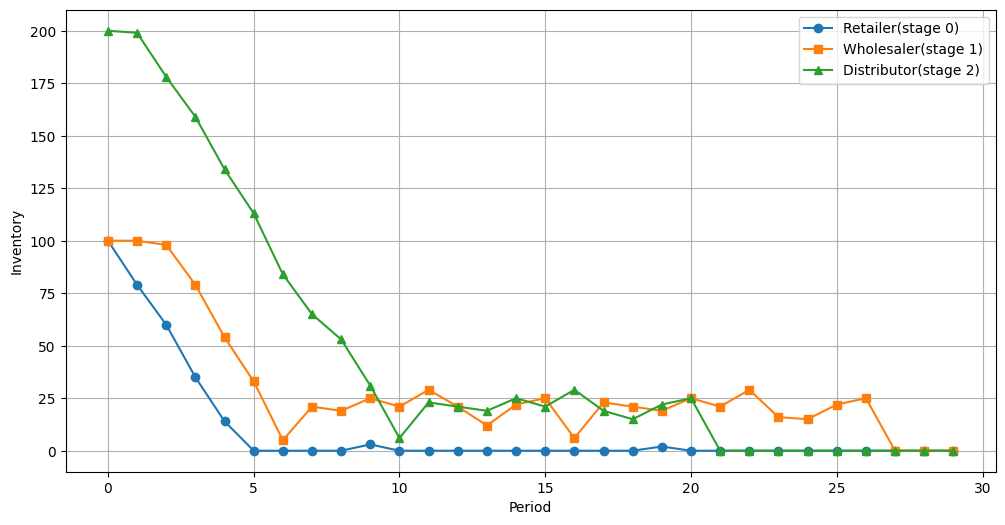

In [20]:
plot_inventory(env)

## 六、Proximal Policy Optimization（PPO）算法

* **Actor (策略网络)**：负责根据当前环境状态（`state`）提取特征并生成动作。假设动作服从正态分布，通过全连接层输出分布的均值（使用 Sigmoid 限制在 [0,1] 范围内并按比例映射到最大产能 `max_action`）。分布的标准差对数被设置为一个独立的可学习参数（`actor_log_std`），允许算法在训练过程中动态减小方差。
>The actor learns a probabilistic policy that produces a probability distribution over available
actions. This distribution is sampled from during training to encourage sufficient exploration
of the state space.
* **Critic (价值网络)**：负责评估当前状态的价值 `V`。它独立处理状态特征，并输出单一的连续数值，以此来指导 Actor 的参数更新。
> The critic learns the value of each state, and the difference between the
predicted value from the critic and the actual rewards received from the environment is used
in the loss function $(L(θ))$ to update the parameters of the networks.
* **损失函数截断**：$$ \mathcal{L}(\theta) = \min(r_t(\theta), \text{clip}(r_t(\theta), 1 - \epsilon, 1 + \epsilon)) \hat{A}_t $$
where $r_t(\theta)$ is the probability ratio between the previous policy, $π_{k−1}(\theta)$, and the new policy
$π_k(\theta)$

#### 算法主要的工作流程分为以下两步：

* **数据采集**：智能体与环境交互时，从 Actor 生成的正态分布中采样具体动作。为了满足约束条件，采样的动作会被截断到区间 `[0, max_action]`。由于这是数据收集阶段，代码使用了 `.detach()` 断开梯度计算图以节省内存。
* **网络更新**：在更新阶段，模型利用收集到的历史状态和动作，重新评估其在当前最新网络下的对数概率、状态价值和分布的“熵”（`dist_entropy`）。这些信息将用于构建 PPO 的损失函数（包括策略损失、价值损失以及熵）。


In [13]:
# 演示代码 后面未使用
class PPOActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(PPOActorCritic, self).__init__()
        
        self.max_action = torch.tensor(max_action, dtype=torch.float32) # 各级最大产能
        
        # Actor
        # 假设动作服从正态分布，通过MLP输出正态分布的均值
        self.actor_fc1 = nn.Linear(state_dim, 128)
        self.actor_fc2 = nn.Linear(128, 128)
        self.actor_mean = nn.Linear(128, action_dim)
        # 可学习参数：正态分布标准差的对数，可通过训练减小方差
        self.actor_log_std = nn.Parameter(torch.zeros(1, action_dim))
        
        # Critic
        self.critic_fc1 = nn.Linear(state_dim, 128)
        self.critic_fc2 = nn.Linear(128, 128)
        self.critic_value = nn.Linear(128, 1) # 状态价值 V

    def forward(self):
        raise NotImplementedError

    def get_action(self, state):
        """根据当前状态输出订货动作，并返回计算 PPO 损失所需的信息"""
        
        a = F.relu(self.actor_fc1(state)) # actor提取特征
        a = F.relu(self.actor_fc2(a))
        
        # 生成动作均值：使用 Sigmoid 限制在 [0,1]，并乘以最大产能
        mean = torch.sigmoid(self.actor_mean(a)) * self.max_action
        std = self.actor_log_std.exp().expand_as(mean)
        dist = Normal(mean, std) # 假设服从正态分布
        
        action = dist.sample()
        action = torch.max(torch.min(action, self.max_action), torch.zeros_like(self.max_action))
        action_log_prob = dist.log_prob(action).sum(dim=-1) # 动作的对数概率
        
        c = F.relu(self.critic_fc1(state)) # critic计算状态价值
        c = F.relu(self.critic_fc2(c))
        state_value = self.critic_value(c)
        
        # 此时不需要计算梯度，detach()断开计算图节省内存
        return action.detach().numpy(), action_log_prob.detach(), state_value.detach()
    
    def evaluate(self, state, action):
        """在更新网络时，重新评估旧动作的概率和价值"""
        # Actor
        a = F.relu(self.actor_fc1(state))
        a = F.relu(self.actor_fc2(a))
        mean = torch.sigmoid(self.actor_mean(a)) * self.max_action
        std = self.actor_log_std.exp().expand_as(mean)
        dist = Normal(mean, std)
        
        action_log_probs = dist.log_prob(action).sum(dim=-1) # 新的对数概率
        dist_entropy = dist.entropy().sum(dim=-1) # 熵
        
        # Critic
        c = F.relu(self.critic_fc1(state))
        c = F.relu(self.critic_fc2(c))
        state_value = self.critic_value(c)
        
        return action_log_probs, state_value, dist_entropy

In [14]:
# 继承类
class SB3SupplyChainEnv(ExactSupplyChainEnv, gym.Env):
    def __init__(self, num_periods=30):
        super().__init__(num_periods=num_periods)
        
        # 动作空间
        self.action_space = spaces.Box(
            low=np.zeros(self.num_stages - 1, dtype=np.float32), 
            high=self.c.astype(np.float32), 
            dtype=np.float32
        )
        
        # 状态空间 
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(self.state_dim,), 
            dtype=np.float32
        )

    def step(self, action):
        discrete_action = np.round(action).astype(int) # PPO输出的是float
        obs, reward, done, info = super().step(discrete_action)
        truncated = False
        return np.array(obs, dtype=np.float32), float(reward), bool(done), truncated, info

    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
        obs = super().reset()
        return np.array(obs, dtype=np.float32), {}


- 引入 VecNormalize 对状态和奖励进行归一化，能够加速神经网络收敛。否则库存和价格数值差异大，容易导致早期训练不稳定。对奖励进行归一化也能使价值评估更平稳。
- `clip_obs` ：对过大的状态值进行截断
- `learning_rate`：学习率衰减，训练早期用较大的学习率快速探索，后期用较小的学习率进行微调
- `n_steps`：PPO 是 on-policy 算法，在更新一次网络前，会在环境中收集 2048 步的数据
- `batch_size`：在优化神经网络时，将收集到的数据打乱，每次抽出 512 条数据组成一个 mini-batch 进行梯度下降
- `n_epoch`：使用收集到的这批数据，重复训练神经网络 10 遍，提升数据利用效率
- `gamma`：折扣因子
- `gae_lambda`：GAE bias-variance trade-off 的参数
- `clip_range`：新旧策略的差异不能超过20%
- `ent_coef`：熵系数，较大则鼓励探索
- `vt_coef`：价值网络误差的权重，PPO 的总损失是由策略损失和价值损失相加得到的
$$L_{total}=L_{policy}+ c_1 L_{critic} - ent\_coef \times S$$

### （可能）有效的改进策略

- **1.传入Inventory Position(IP)**：（微弱提升）$$IP_t^m = I_t^m + T_t^m - B_{t-1}^m$$

- **2.动作空间归一化**：PPO 默认输出的动作是从均值为 0、标准差为 1 的高斯分布中采样的。如果不进行归一化，直接让网络在 $[0, 100]$ 这样的动作空间中拟合，早期策略会因为均值初始在 0 附近而产生严重的偏差。在环境中统一映射到 $[-1, 1]$ 能帮助神经网络平稳收敛。（严重下降）
- **3.超参数调优**：如增大`n_steps`，线性衰减`ent_coef`（反而下降）。
- **4.增加残值奖励**：见 section 11，有一定效果。（407 -> 410）

**由于单次训练模型时间较久，这里将之前训练好的模型保存在 ./ppo_supply_chain 文件夹下**

In [ ]:
# vec_env = DummyVecEnv([lambda: Monitor(SB3SupplyChainEnv())])
# # 归一化，提升训练稳定性
# vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True, clip_obs=1000.0, gamma=0.97)

# model = PPO(
#     "MlpPolicy",
#     vec_env,
#     verbose=1,
#     learning_rate=lambda progress: 3e-4 * (0.1 + 0.9 * progress),
#     n_steps=2048,
#     batch_size=512,
#     n_epochs=10,
#     gamma=0.97,
#     gae_lambda=0.95,
#     clip_range=0.2,
#     ent_coef=0.05,
#     vf_coef=0.5,
#     seed=42,   
#     policy_kwargs=dict(net_arch=[256, 256]),
#     tensorboard_log="./ppo_tensorboard/"
# )

# print("--- 开始训练 PPO 智能体 ---")
# model.learn(total_timesteps=1000000)
# print("\n--- 训练完成 ---")


# SAVE_DIR = r".\ppo_supply_chain"
# os.makedirs(SAVE_DIR, exist_ok=True)
# model.save(os.path.join(SAVE_DIR, "model1"))
# vec_env.save(os.path.join(SAVE_DIR, "vec_normalize1.pkl"))
# print(f"模型已保存至: {SAVE_DIR}/model1.zip")
# print(f"归一化统计量已保存至: {SAVE_DIR}/vec_normalize1.pkl")

In [ ]:
# vec_env.training = False
# vec_env.norm_reward = False

# np.random.seed(42)
# eval_seed_env = DummyVecEnv([lambda: SB3SupplyChainEnv()])
# eval_seed_env = VecNormalize(eval_seed_env, norm_obs=True, norm_reward=False, clip_obs=1000.0, gamma=0.97, training=False)
# eval_seed_env.obs_rms = vec_env.obs_rms

# mean_reward, std_reward = evaluate_policy(model, eval_seed_env, n_eval_episodes=100, deterministic=True)
# print(f"\nPPO 模型 100 次测试平均折现总利润: {mean_reward:.2f} +/- {std_reward:.2f}")
# np.random.seed(42)
# eval_env = SB3SupplyChainEnv()
# obs, _ = eval_env.reset(seed=40)
# obs_normalized = vec_env.normalize_obs(obs)

# done = False
# truncated = False
# total_profit = 0

# print(f"\n{'天数':<5} | {'需求':<5} | {'零销量':<6} | {'动作(R, W, D)':<15} | {'期末库存':<15} | {'本日利润':<8}")
# print("-" * 70)
# while not (done or truncated):
#     action, _states = model.predict(obs_normalized, deterministic=True)
#     obs, reward, done, truncated, info = eval_env.step(action)
#     obs_normalized = vec_env.normalize_obs(obs)
#     total_profit += reward
#     print(f"{eval_env.current_step:<6} | {info['demand']:<7} | {info['sales'][0]:<8.0f} | "
#           f"{str(np.round(action).astype(int)):<17} | "
#           f"{str(eval_env.I[eval_env.current_step, :].astype(int)):<17} | {reward:<8.2f}")

# print("-" * 70)
# print(f"单次演示 PPO 总折现利润: {total_profit:.2f}")


- 每次训练耗时较长，可以从 ./ppo_supply_chain 文件夹直接加载训练好的模型，注意相对路径

In [ ]:
SAVE_DIR = r".\ppo_supply_chain" # 相对位置
loaded_vec_env = DummyVecEnv([lambda: SB3SupplyChainEnv()])
loaded_vec_env = VecNormalize.load(
    os.path.join(SAVE_DIR, "vec_normalize1.pkl"),
    loaded_vec_env
)
loaded_vec_env.training = False
loaded_vec_env.norm_reward = False
loaded_model = PPO.load(
    os.path.join(SAVE_DIR, "model1"),
    env=loaded_vec_env
)
print("模型加载成功！")

np.random.seed(42)
eval_seed_env = DummyVecEnv([lambda: SB3SupplyChainEnv()])
eval_seed_env = VecNormalize(eval_seed_env, norm_obs=True, norm_reward=False, clip_obs=1000.0, gamma=0.97, training=False)
eval_seed_env.obs_rms = loaded_vec_env.obs_rms

mean_reward, std_reward = evaluate_policy(loaded_model, eval_seed_env, n_eval_episodes=100, deterministic=True)
print(f"加载模型 100 次测试平均折现总利润: {mean_reward:.2f} +/- {std_reward:.2f}")


np.random.seed(45)
eval_env = SB3SupplyChainEnv()
obs, _ = eval_env.reset(seed=450)
obs_normalized = loaded_vec_env.normalize_obs(obs)
done = False
truncated = False
total_profit = 0
print(f"\n{'天数':<5} | {'需求':<5} | {'零销量':<6} | {'动作(R, W, D)':<15} | {'期末库存':<15} | {'本日利润':<8}")
print("-" * 70)
while not (done or truncated):
    action, _ = loaded_model.predict(obs_normalized, deterministic=True)
    obs, reward, done, truncated, info = eval_env.step(action)
    obs_normalized = loaded_vec_env.normalize_obs(obs)
    total_profit += reward
    print(f"{eval_env.current_step:<6} | {info['demand']:<7} | {info['sales'][0]:<8.0f} | "
          f"{str(np.round(action).astype(int)):<17} | "
          f"{str(eval_env.I[eval_env.current_step, :].astype(int)):<17} | {reward:<8.2f}")

print("-" * 70)
print(f"单次演示 PPO 总折现利润: {total_profit:.2f}")


模型加载成功！


e:\Miniconda3\envs\rl\lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


加载模型 100 次测试平均折现总利润: 404.27 +/- 22.05

天数    | 需求    | 零销量    | 动作(R, W, D)     | 期末库存            | 本日利润    
----------------------------------------------------------------------
1      | 24      | 24       | [ 4 19  0]        | [ 76  96 181]     | 17.95   
2      | 24      | 24       | [13 18  0]        | [ 52  83 163]     | 23.04   
3      | 18      | 18       | [21 19  0]        | [ 34  62 144]     | 16.47   
4      | 28      | 28       | [25 23  0]        | [ 10  37 121]     | 40.84   
5      | 15      | 15       | [19 25  0]        | [ 8 18 96]        | 19.65   
6      | 28      | 28       | [16 25  0]        | [ 1 21 71]        | 43.11   
7      | 21      | 21       | [17 24  0]        | [ 5 22 47]        | 30.57   
8      | 19      | 19       | [20 21  0]        | [ 5 21 26]        | 27.35   
9      | 18      | 18       | [20 16  0]        | [ 3 24 10]        | 25.59   
10     | 20      | 20       | [23 13  0]        | [ 0 26  0]        | 28.32   
11     | 18      | 18       | 

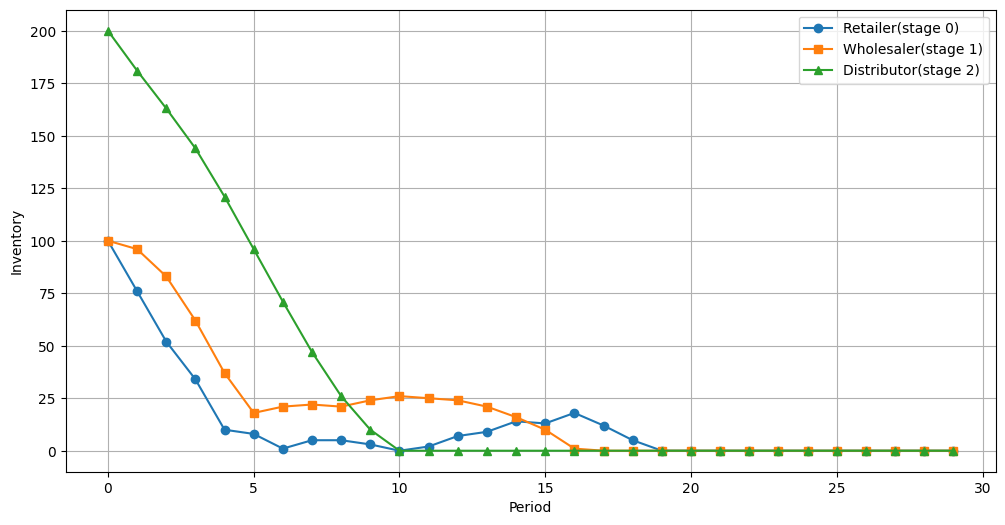

In [23]:
plot_inventory(eval_env)

## 七、Oracle（确定需求）

Oracle 模型本质上是一个**线性规划（LP）模型**。由于每一期实际的真实需求都已经被提前知晓，问题从一个带有随机不确定性的动态规划问题，退化为一个个确定性的多阶段全局最优化问题。代码演示中使用了 Python 的 `pulp` 库来构建并求解该 LP 问题。

算法的全局优化目标是在有限的运行周期内，**最大化整个供应链系统的折现总利润**。
总利润的计算涵盖四个核心经济指标：
* **+ 销售收益** 
* **- 采购与生产成本**
* **- 缺货惩罚成本** 
* **- 仓储成本** 

约束条件为：
* **库存守恒**：当前节点的可用库存必须等于前一天的结余库存，加上经过提前期后当日送达的货物量。
* **产能与库存上限**：各节点发出的补货订单不能超过最大产能限制，同时也受到其上游节点当天可用库存的约束。
* **缺货积压**：零售商的销量不能超过自身可用库存，也不能超过当天新需求 + 历史缺货积压的总和，未能满足的部分成为新的缺货积压。

In [15]:
def oracle(env, demand_sequence):
    """
    需求确定下的最优利润
    profit = sum(unit_price * S) - sum(r * RR) - sum(k * U) - sum(holding_cost * II)
    其中 S = [S0, R0, R1, R2], RR = [R0, R1, R2, S_last]
    """
    T = env.num_periods
    M = env.num_stages - 1  
    model = pulp.LpProblem("Supply_Chain_Oracle", pulp.LpMaximize) # 定义一个最大化问题
  
    R = pulp.LpVariable.dicts("R", ((t, m) for t in range(T) for m in range(M)), lowBound=0) # R[t, m]: 节点 m 在第 t 天发出的补货订单量
    I_start = pulp.LpVariable.dicts("I_start", ((t, m) for t in range(T+1) for m in range(M)), lowBound=0) # I_start[t, m]: 节点 m 在第 t 天的期初库存
    I_avail = pulp.LpVariable.dicts("I_avail", ((t, m) for t in range(T) for m in range(M)), lowBound=0) # I_avail[t, m]: 节点 m 在第 t 天的可用库存
    S = pulp.LpVariable.dicts("S", ((t, m) for t in range(T) for m in range(M)), lowBound=0) # S[t, m]: 节点 m 在第 t 天的销售量
    B = pulp.LpVariable.dicts("B", ((t, m) for t in range(T) for m in range(M)), lowBound=0) # B[t, m]: 节点 m 在第 t 天的缺货量
    
    for m in range(M):
        model += I_start[0, m] == env.I0[m] # 初始库存
            
    for t in range(T):
        for m in range(M):
            order_time = t - env.L[m] # 计算提前期后的到货时间
            if order_time < 0:
                arrival = 0
            else:
                arrival = R[order_time, m]
            model += I_avail[t, m] == I_start[t, m] + arrival # 可用库存 = 期初库存 + 到货量
            model += R[t, m] <= env.c[m] # 产能约束
            
        for m in range(M - 1):
            model += R[t, m] <= I_avail[t, m+1] # 上游库存约束：当前节点下的订单，不能超过其上游节点今天的可用库存
            
        D_t = demand_sequence[t]
        B_prev = B[t-1, 0] if t > 0 else 0 # 缺货积压
        model += S[t, 0] <= I_avail[t, 0] # 零售商实际销量不能超过可用库存
        model += S[t, 0] <= D_t + B_prev # 零售商实际销量不能超过当天新需求 +缺货积压的总和
        model += B[t, 0] == D_t + B_prev - S[t, 0] # 缺货积压 = 总需求 - 今天实际发货量
        
        # 上游节点满足下游的补货需求
        for m in range(1, M):
            model += S[t, m] == R[t, m-1]
            model += B[t, m] == 0 
        
        # 明天的期初库存 = 今天的可用总库存 - 今天发出去的货
        for m in range(M):
            model += I_start[t+1, m] == I_avail[t, m] - S[t, m]
            
    # S_sim = [S0, R0, R1, R2], RR_sim = [R0, R1, R2, R2]
    # unit_price = [p, r0, r1, r2] = [2.0, 1.5, 1.0, 0.75]
    # r = [r0, r1, r2, r3] = [1.5, 1.0, 0.75, 0.5]
    total_profit = 0
    for t in range(T):
        discount = env.alpha ** t
        
        # 销售收入
        revenue = env.unit_price[0] * S[t, 0]
        for m in range(M):
            revenue += env.unit_price[m + 1] * R[t, m]  # 上游各级的销售收入
        
        # 采购成本
        proc_cost = pulp.lpSum(env.r[m] * R[t, m] for m in range(M))
        proc_cost += env.r[M] * R[t, M-1]  # 工厂生产成本
        
        # 缺货惩罚 
        penalty = pulp.lpSum(env.k[m] * B[t, m] for m in range(M))
        
        # 仓储成本
        holding = pulp.lpSum(env.holding_cost[m] * I_start[t+1, m] for m in range(M))
        
        total_profit += discount * (revenue - proc_cost - penalty - holding)
        
    model += total_profit
    model.solve(pulp.PULP_CBC_CMD(msg=False))
    
    if pulp.LpStatus[model.status] == 'Optimal':
        return pulp.value(model.objective)
    else:
        return None


def generate_demands(env, episodes=20):
    """生成测试集需求序列（种子与训练集完全隔离）"""
    sequences = []
    for ep in range(episodes):
        np.random.seed(2000 + ep)  # 测试集种子，与 evaluate_z 的训练集种子（1000+）完全隔离
        demands = np.random.poisson(env.demand_lambda, size=env.num_periods)
        sequences.append(demands)
    return sequences

In [16]:
env = ExactSupplyChainEnv()
demand_sequences = generate_demands(env, episodes=20)

oracle_profits = []
for seq in demand_sequences:
    profit = oracle(env, seq)
    if profit is not None:
        oracle_profits.append(profit)

avg_oracle = np.mean(oracle_profits)
print(f"Oracle（确定需求）20 次平均折现总利润: {avg_oracle:.2f}")

Oracle（确定需求）20 次平均折现总利润: 594.86


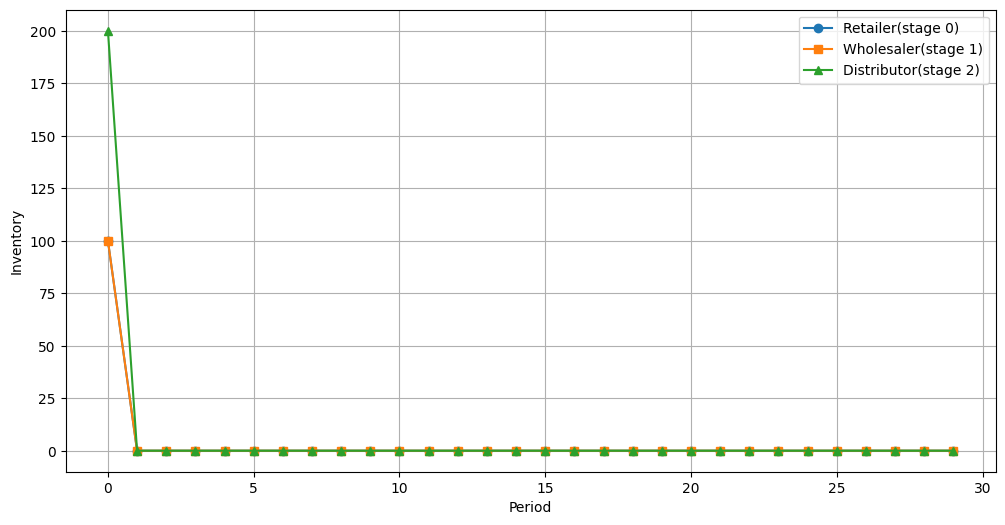

In [26]:
plot_inventory(env)

## 八、相同需求序列下的算法对比

在完全相同的 20 条需求序列下评估：
- Base Stock + DFO (rounding)
- Base Stock + DFO (local search)
- Base Stock + SA
- SHLP
- PPO
- Oracle

In [17]:
import time

def eval_fixed(env, policy, demands):
    """
    在固定需求序列上评估任意策略函数
    """
    profits = []
    for demand in demands:
        env.reset()
        demand_iter = iter(demand)
        original_poisson = np.random.poisson

        def fixed_poisson(lam=None, size=None):
            return next(demand_iter)
        np.random.poisson = fixed_poisson
        ep_profit = 0
        done = False
        while not done:
            action = policy(env)
            _, reward, done, _ = env.step(action)
            ep_profit += reward
        np.random.poisson = original_poisson
        profits.append(ep_profit)
    return profits


def eval_shlp(env, mu_hat, demands):
    """
    在固定需求序列上评估 SHLP 策略，确保与其他算法使用相同需求。
    """
    profits = []
    for demand in demands:
        env.reset()
        demand_iter = iter(demand)
        original_poisson = np.random.poisson

        def fixed_poisson(lam=None, size=None):
            return next(demand_iter)
        np.random.poisson = fixed_poisson
        ep_profit = 0
        done = False
        while not done:
            action = SHLP(env, mu_hat)
            _, reward, done, _ = env.step(action)
            ep_profit += reward
        np.random.poisson = original_poisson
        profits.append(ep_profit)
    return profits


def eval_ppo(model, vec_env, demands):
    """
    在固定需求序列上评估 PPO 策略，确保与其他算法使用相同需求。
    """
    profits = []
    for demand in demands:
        eval_env = SB3SupplyChainEnv(num_periods=len(demand))
        eval_env.reset()
        demand_iter = iter(demand)
        original_poisson = np.random.poisson

        def fixed_poisson(lam=None, size=None):
            return next(demand_iter)
        np.random.poisson = fixed_poisson
        obs, _ = eval_env.reset()
        obs_norm = vec_env.normalize_obs(obs)
        done = False
        truncated = False
        ep_profit = 0
        while not (done or truncated):
            action, _ = model.predict(obs_norm, deterministic=True)
            obs, reward, done, truncated, info = eval_env.step(action)
            obs_norm = vec_env.normalize_obs(obs)
            ep_profit += reward
        np.random.poisson = original_poisson
        profits.append(ep_profit)
    return profits


def _timeit(fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    elapsed = time.perf_counter() - t0
    return out, elapsed

def test1(episodes=20):
    '''评估所有算法在相同需求序列上的表现，输出平均利润、标准差和运行时间'''
    env = ExactSupplyChainEnv()
    demands = generate_demands(env, episodes=episodes)
    n_eps = len(demands)

    runtime_sec = {}

    # Oracle 基准
    oracle_profits, runtime_sec['Oracle'] = _timeit(
        lambda: [oracle(env, seq) for seq in demands]
    )
    avg_oracle = np.mean(oracle_profits)
    std_oracle = np.std(oracle_profits)

    # Base Stock + DFO (rounding)
    dfo_profits_round, runtime_sec['Base Stock + DFO (rounding)'] = _timeit(
        eval_fixed,
        env,
        lambda e: base_stock(e, z_DFO_round),
        demands
    )
    avg_dfo_round = np.mean(dfo_profits_round)
    std_dfo_round = np.std(dfo_profits_round)

    # Base Stock + DFO (local search)
    dfo_profits_search, runtime_sec['Base Stock + DFO (local search)'] = _timeit(
        eval_fixed,
        env,
        lambda e: base_stock(e, best_z_local),
        demands
    )
    avg_dfo_search = np.mean(dfo_profits_search)
    std_dfo_search = np.std(dfo_profits_search)

    # Base Stock + SA
    sa_profits, runtime_sec['Base Stock + SA'] = _timeit(
        eval_fixed,
        env,
        lambda e: base_stock(e, z_SA),
        demands
    )
    avg_sa = np.mean(sa_profits)
    std_sa = np.std(sa_profits)

    # SHLP
    print("正在评估 SHLP（每步求解 LP，耗时较长）...")
    shlp_profits, runtime_sec['SHLP'] = _timeit(eval_shlp, env, mu_hat, demands)
    avg_shlp = np.mean(shlp_profits)
    std_shlp = np.std(shlp_profits)

    # PPO
    SAVE_DIR = r".\ppo_supply_chain"
    _ppo_vec = DummyVecEnv([lambda: SB3SupplyChainEnv()])
    _ppo_vec = VecNormalize.load(os.path.join(SAVE_DIR, "vec_normalize1.pkl"), _ppo_vec)
    _ppo_vec.training = False
    _ppo_vec.norm_reward = False
    _ppo_model = PPO.load(os.path.join(SAVE_DIR, "model1"), env=_ppo_vec)

    ppo_profits, runtime_sec['PPO'] = _timeit(eval_ppo, _ppo_model, _ppo_vec, demands)
    avg_ppo = np.mean(ppo_profits)
    std_ppo = np.std(ppo_profits)

    print(f"\n{'算法':<28} {'平均折现总利润':>14} {'标准差':>10} {'占 Oracle %':>12}")
    print("-" * 66)
    print(f"{'Oracle':<28} {avg_oracle:>14.2f} {std_oracle:>10.2f} {'100.00%':>12}")
    print(f"{'Base Stock + DFO (rounding)':<28} {avg_dfo_round:>14.2f} {std_dfo_round:>10.2f} {avg_dfo_round/avg_oracle*100:>11.1f}%")
    print(f"{'Base Stock + DFO (local search)':<28} {avg_dfo_search:>14.2f} {std_dfo_search:>10.2f} {avg_dfo_search/avg_oracle*100:>11.1f}%")
    print(f"{'Base Stock + SA':<28} {avg_sa:>14.2f} {std_sa:>10.2f} {avg_sa/avg_oracle*100:>11.1f}%")
    print(f"{'SHLP':<28} {avg_shlp:>14.2f} {std_shlp:>10.2f} {avg_shlp/avg_oracle*100:>11.1f}%")
    print(f"{'PPO':<28} {avg_ppo:>14.2f} {std_ppo:>10.2f} {avg_ppo/avg_oracle*100:>11.1f}%")

    print(f"\n{'算法':<28} {'总运行时间(s)':>14} {'单Episode(s)':>14} ")
    print("-" * 74)
    min_t = min(runtime_sec.values())
    for name in ['Oracle', 'Base Stock + DFO (rounding)', 'Base Stock + DFO (local search)', 'Base Stock + SA', 'SHLP', 'PPO']:
        t = runtime_sec[name]
        print(f"{name:<28} {t:>14.3f} {t/n_eps:>14.3f} ")
    return avg_dfo_round, std_dfo_round, avg_dfo_search, std_dfo_search, avg_sa, std_sa, avg_shlp, std_shlp, avg_ppo, std_ppo

#### 探究各算法在不同 episodes 上的表现/运行时间

- episodes = 20

In [18]:
avg_dfo_round, std_dfo_round, avg_dfo_search, std_dfo_search, avg_sa, std_sa, avg_shlp, std_shlp, avg_ppo, std_ppo = test1(episodes=20)

正在评估 SHLP（每步求解 LP，耗时较长）...

算法                                  平均折现总利润        标准差   占 Oracle %
------------------------------------------------------------------
Oracle                               594.86      37.30      100.00%
Base Stock + DFO (rounding)          310.40      46.52        52.2%
Base Stock + DFO (local search)         307.84      40.00        51.8%
Base Stock + SA                      310.38      98.34        52.2%
SHLP                                 523.07      25.96        87.9%
PPO                                  407.62      20.68        68.5%

算法                                 总运行时间(s)    单Episode(s) 
--------------------------------------------------------------------------
Oracle                                0.784          0.039 
Base Stock + DFO (rounding)           0.023          0.001 
Base Stock + DFO (local search)          0.024          0.001 
Base Stock + SA                       0.024          0.001 
SHLP                                 21.407    

- episodes = 50

In [22]:
_,_,_,_,_,_,_,_,_,_= test1(episodes=50)

正在评估 SHLP（每步求解 LP，耗时较长）...

算法                                  平均折现总利润        标准差   占 Oracle %
------------------------------------------------------------------
Oracle                               593.82      36.84      100.00%
Base Stock + DFO (rounding)          318.39      38.62        53.6%
Base Stock + DFO (local search)         314.35      35.26        52.9%
Base Stock + SA                      326.47      67.93        55.0%
SHLP                                 527.59      29.04        88.8%
PPO                                  406.53      20.08        68.5%

算法                                 总运行时间(s)    单Episode(s) 
--------------------------------------------------------------------------
Oracle                                2.048          0.041 
Base Stock + DFO (rounding)           0.061          0.001 
Base Stock + DFO (local search)          0.058          0.001 
Base Stock + SA                       0.058          0.001 
SHLP                                 62.472    

#### 探究各算法在不同周期长度上的运行时间

In [19]:
def test2(episodes=20,num_periods=30):
    '''评估所有算法在不同周期上的运行时间'''
    env = ExactSupplyChainEnv(num_periods=num_periods)
    demands = generate_demands(env, episodes=episodes)
    n_eps = len(demands)
    runtime_sec = {}

    # Oracle 基准
    oracle_profits, runtime_sec['Oracle'] = _timeit(
        lambda: [oracle(env, seq) for seq in demands]
    )

    # Base Stock + DFO (rounding)
    dfo_profits_round, runtime_sec['Base Stock + DFO (rounding)'] = _timeit(
        eval_fixed,
        env,
        lambda e: base_stock(e, z_DFO_round),
        demands
    )

    # Base Stock + DFO (local search)
    dfo_profits_search, runtime_sec['Base Stock + DFO (local search)'] = _timeit(
        eval_fixed,
        env,
        lambda e: base_stock(e, best_z_local),
        demands
    )

    # Base Stock + SA
    sa_profits, runtime_sec['Base Stock + SA'] = _timeit(
        eval_fixed,
        env,
        lambda e: base_stock(e, z_SA),
        demands
    )

    # SHLP
    print("正在评估 SHLP（每步求解 LP，耗时较长）...")
    shlp_profits, runtime_sec['SHLP'] = _timeit(eval_shlp, env, mu_hat, demands)
 
    # PPO
    # 由于PPO是在T=30的环境中训练的，此时利润会很低
    SAVE_DIR = r".\ppo_supply_chain"
    _ppo_vec = DummyVecEnv([lambda: SB3SupplyChainEnv()])
    _ppo_vec = VecNormalize.load(os.path.join(SAVE_DIR, "vec_normalize1.pkl"), _ppo_vec)
    _ppo_vec.training = False
    _ppo_vec.norm_reward = False
    _ppo_model = PPO.load(os.path.join(SAVE_DIR, "model1"), env=_ppo_vec)

    ppo_profits, runtime_sec['PPO'] = _timeit(eval_ppo, _ppo_model, _ppo_vec, demands)
   

    print(f"\n{'算法':<28} {'总运行时间(s)':>14} {'单Episode(s)':>14} ")
    print("-" * 74)
    min_t = min(runtime_sec.values())
    for name in ['Oracle', 'Base Stock + DFO (rounding)', 'Base Stock + DFO (local search)', 'Base Stock + SA', 'SHLP', 'PPO']:
        t = runtime_sec[name]
        print(f"{name:<28} {t:>14.3f} {t/n_eps:>14.3f} ")
test2(episodes=20,num_periods=50) # T = 50

正在评估 SHLP（每步求解 LP，耗时较长）...

算法                                 总运行时间(s)    单Episode(s) 
--------------------------------------------------------------------------
Oracle                                0.984          0.049 
Base Stock + DFO (rounding)           0.040          0.002 
Base Stock + DFO (local search)          0.043          0.002 
Base Stock + SA                       0.045          0.002 
SHLP                                 42.913          2.146 
PPO                                   0.453          0.023 


In [24]:
test2(episodes=20,num_periods=100) # T = 100

正在评估 SHLP（每步求解 LP，耗时较长）...

算法                                 总运行时间(s)    单Episode(s) 
--------------------------------------------------------------------------
Oracle                                1.530          0.076 
Base Stock + DFO (rounding)           0.079          0.004 
Base Stock + DFO (local search)          0.075          0.004 
Base Stock + SA                       0.076          0.004 
SHLP                                128.640          6.432 
PPO                                   0.872          0.044 


## 九、可视化分析

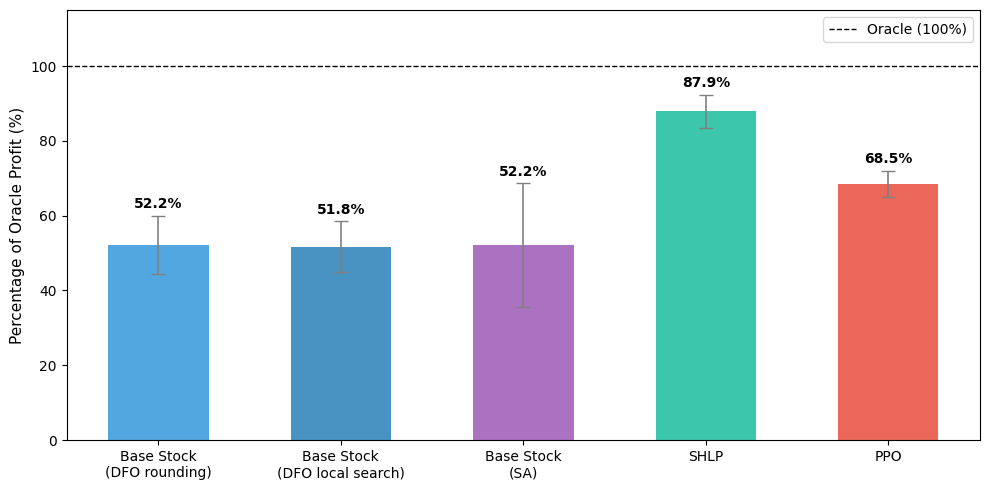

In [20]:
# 模拟数据（泊松分布）各算法占 Oracle 比
sim_algo_names = [
    "Base Stock\n(DFO rounding)",
    "Base Stock\n(DFO local search)",
    "Base Stock\n(SA)",
    "SHLP",
    "PPO",
]
sim_avgs = [avg_dfo_round, avg_dfo_search, avg_sa, avg_shlp, avg_ppo]
sim_stds = [std_dfo_round, std_dfo_search, std_sa, std_shlp, std_ppo]
sim_ratios = [v / avg_oracle * 100 for v in sim_avgs]
sim_ratio_stds = [s / avg_oracle * 100 for s in sim_stds]

colors = ["#3498db", "#2980b9", "#9b59b6", "#1abc9c", "#e74c3c"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(sim_algo_names))
bars = ax.bar(x, sim_ratios, yerr=sim_ratio_stds, capsize=5,
              color=colors, alpha=0.85, width=0.55,
              error_kw=dict(elinewidth=1.2, ecolor="gray"))

ax.axhline(y=100, color="black", ls="--", lw=1.0, label="Oracle (100%)")
ax.set_xticks(x)
ax.set_xticklabels(sim_algo_names, fontsize=10)
ax.set_ylabel("Percentage of Oracle Profit (%)", fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)

for bar, r, s in zip(bars, sim_ratios, sim_ratio_stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 1.2,
            f"{r:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


In [21]:
demands = generate_demands(env, episodes=20)
# PPO
SAVE_DIR = r".\ppo_supply_chain"
_ppo_vec = DummyVecEnv([lambda: SB3SupplyChainEnv()])
_ppo_vec = VecNormalize.load(os.path.join(SAVE_DIR, "vec_normalize1.pkl"), _ppo_vec)
_ppo_vec.training = False
_ppo_vec.norm_reward = False
_ppo_model = PPO.load(os.path.join(SAVE_DIR, "model1"), env=_ppo_vec)

def collect_step_data(env, policy, demands):
    """
    在固定需求序列上运行策略，收集每步的累积奖励、库存、订货量和需求。
    返回:
        cum_rewards : (n_ep, T)
        inventories : (n_ep, T, M-1)
        orders      : (n_ep, T, M-1)
        demand_arr  : (n_ep, T)
    """
    cum_rewards, inventories, orders, demand_arr = [], [], [], []
    for demand in demands:
        env.reset()
        demand_iter = iter(demand)
        _orig = np.random.poisson
        np.random.poisson = lambda lam=None, size=None: next(demand_iter)
        cum, done = 0, False
        step_rewards = []
        while not done:
            action = policy(env)
            _, reward, done, _ = env.step(action)
            cum += reward
            step_rewards.append(cum)
        np.random.poisson = _orig
        cum_rewards.append(step_rewards)
        inventories.append(env.I[:env.num_periods].copy())
        orders.append(env.action_log.copy())
        demand_arr.append(env.D.copy())
    return (np.array(cum_rewards), np.array(inventories),
            np.array(orders), np.array(demand_arr))


def collect_step_data_shlp(env, mu_hat, demands):
    cum_rewards, inventories, orders, demand_arr = [], [], [], []
    for demand in demands:
        env.reset()
        demand_iter = iter(demand)
        _orig = np.random.poisson
        np.random.poisson = lambda lam=None, size=None: next(demand_iter)
        cum, done = 0, False
        step_rewards = []
        while not done:
            action = SHLP(env, mu_hat)
            _, reward, done, _ = env.step(action)
            cum += reward
            step_rewards.append(cum)
        np.random.poisson = _orig
        cum_rewards.append(step_rewards)
        inventories.append(env.I[:env.num_periods].copy())
        orders.append(env.action_log.copy())
        demand_arr.append(env.D.copy())
    return (np.array(cum_rewards), np.array(inventories),
            np.array(orders), np.array(demand_arr))


def collect_step_data_ppo(model, vec_env_ref, demands):
    cum_rewards, inventories, orders, demand_arr = [], [], [], []
    for demand in demands:
        eval_env = SB3SupplyChainEnv()
        eval_env.reset()
        demand_iter = iter(demand)
        _orig = np.random.poisson
        np.random.poisson = lambda lam=None, size=None: next(demand_iter)
        obs, _ = eval_env.reset()
        obs_norm = vec_env_ref.normalize_obs(obs)
        done = truncated = False
        cum = 0
        step_rewards = []
        while not (done or truncated):
            action, _ = model.predict(obs_norm, deterministic=True)
            obs, reward, done, truncated, _ = eval_env.step(action)
            obs_norm = vec_env_ref.normalize_obs(obs)
            cum += reward
            step_rewards.append(cum)
        np.random.poisson = _orig
        cum_rewards.append(step_rewards)
        inventories.append(eval_env.I[:eval_env.num_periods].copy())
        orders.append(eval_env.action_log.copy())
        demand_arr.append(eval_env.D.copy())
    return (np.array(cum_rewards), np.array(inventories),
            np.array(orders), np.array(demand_arr))


def collect_step_data_oracle(env, demands):
    """通过求解 LP 提取 Oracle 的逐步累积奖励、库存和订货量。"""
    cum_rewards, inventories, orders, demand_arr = [], [], [], []
    for demand_seq in demands:
        T = env.num_periods
        M = env.num_stages - 1
        lp = pulp.LpProblem("SC_Oracle_Step", pulp.LpMaximize)
        R = pulp.LpVariable.dicts("R", ((t, m) for t in range(T) for m in range(M)), lowBound=0)
        I_start = pulp.LpVariable.dicts("I_start", ((t, m) for t in range(T+1) for m in range(M)), lowBound=0)
        I_avail = pulp.LpVariable.dicts("I_avail", ((t, m) for t in range(T) for m in range(M)), lowBound=0)
        S = pulp.LpVariable.dicts("S", ((t, m) for t in range(T) for m in range(M)), lowBound=0)
        B = pulp.LpVariable.dicts("B", ((t, m) for t in range(T) for m in range(M)), lowBound=0)
        for m in range(M):
            lp += I_start[0, m] == env.I0[m]
        for t in range(T):
            for m in range(M):
                order_time = t - env.L[m]
                arrival = R[order_time, m] if order_time >= 0 else 0
                lp += I_avail[t, m] == I_start[t, m] + arrival
                lp += R[t, m] <= env.c[m]
            for m in range(M - 1):
                lp += R[t, m] <= I_avail[t, m+1]
            D_t = demand_seq[t]
            B_prev = B[t-1, 0] if t > 0 else 0
            lp += S[t, 0] <= I_avail[t, 0]
            lp += S[t, 0] <= D_t + B_prev
            lp += B[t, 0] == D_t + B_prev - S[t, 0]
            for m in range(1, M):
                lp += S[t, m] == R[t, m-1]
                lp += B[t, m] == 0
            for m in range(M):
                lp += I_start[t+1, m] == I_avail[t, m] - S[t, m]
        total_profit = 0
        for t in range(T):
            discount = env.alpha ** t
            revenue = env.unit_price[0] * S[t, 0]
            for m in range(M):
                revenue += env.unit_price[m + 1] * R[t, m]
            proc_cost = pulp.lpSum(env.r[m] * R[t, m] for m in range(M))
            proc_cost += env.r[M] * R[t, M-1]
            penalty = pulp.lpSum(env.k[m] * B[t, m] for m in range(M))
            holding = pulp.lpSum(env.holding_cost[m] * I_start[t+1, m] for m in range(M))
            total_profit += discount * (revenue - proc_cost - penalty - holding)
        lp += total_profit
        lp.solve(pulp.PULP_CBC_CMD(msg=False))
        step_rewards, inv_traj, ord_traj = [], [], []
        cum = 0
        for t in range(T):
            discount = env.alpha ** t
            rev = env.unit_price[0] * pulp.value(S[t, 0])
            for m in range(M):
                rev += env.unit_price[m + 1] * pulp.value(R[t, m])
            pc = sum(env.r[m] * pulp.value(R[t, m]) for m in range(M))
            pc += env.r[M] * pulp.value(R[t, M-1])
            pen = sum(env.k[m] * pulp.value(B[t, m]) for m in range(M))
            hold = sum(env.holding_cost[m] * pulp.value(I_start[t+1, m]) for m in range(M))
            cum += discount * (rev - pc - pen - hold)
            step_rewards.append(cum)
            inv_traj.append([pulp.value(I_start[t+1, m]) for m in range(M)])
            ord_traj.append([pulp.value(R[t, m]) for m in range(M)])
        cum_rewards.append(step_rewards)
        inventories.append(inv_traj)
        orders.append(ord_traj)
        demand_arr.append(demand_seq)
    return (np.array(cum_rewards), np.array(inventories),
            np.array(orders), np.array(demand_arr))


# 收集所有算法的数据
env = ExactSupplyChainEnv()
print("收集 Base Stock + DFO (rounding) 数据...")
dfo_r_cr, dfo_r_inv, dfo_r_ord, dfo_r_dem = collect_step_data(
    env, lambda e: base_stock(e, z_DFO_round), demands)

print("收集 Base Stock + DFO (local search) 数据...")
dfo_s_cr, dfo_s_inv, dfo_s_ord, dfo_s_dem = collect_step_data(
    env, lambda e: base_stock(e, best_z_local), demands)

print("收集 Base Stock + SA 数据...")
sa_cr, sa_inv, sa_ord, sa_dem = collect_step_data(
    env, lambda e: base_stock(e, z_SA), demands)

print("收集 SHLP 数据...")
shlp_cr, shlp_inv, shlp_ord, shlp_dem = collect_step_data_shlp(env, mu_hat, demands)

print("收集 PPO 数据...")
ppo_cr, ppo_inv, ppo_ord, ppo_dem = collect_step_data_ppo(_ppo_model, _ppo_vec, demands)

print("收集 Oracle 数据...")
oracle_cr, oracle_inv, oracle_ord, oracle_dem = collect_step_data_oracle(env, demands)

print("数据收集完成！")


收集 Base Stock + DFO (rounding) 数据...
收集 Base Stock + DFO (local search) 数据...
收集 Base Stock + SA 数据...
收集 SHLP 数据...
收集 PPO 数据...
收集 Oracle 数据...
数据收集完成！


### 1. 累积奖励随时间变化（20 个 Episode 均值 ± 标准差）

In [22]:
def plot_cumulative_rewards(algo_data, colors):
    """绘制各算法累积奖励随时间变化曲线（均值 ± 标准差）"""
    periods = np.arange(1, 31)
    fig, ax = plt.subplots(figsize=(10, 8))
    for (label, cr), color in zip(algo_data.items(), colors):
        mean = np.mean(cr, axis=0)
        std  = np.std(cr,  axis=0)
        ax.plot(periods, mean, label=label, color=color, linewidth=1.8)
        ax.fill_between(periods, mean - std, mean + std, alpha=0.15, color=color)
    ax.set_xlabel("Day", fontsize=12)
    ax.set_ylabel("Rewards", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_inventory_levels(inv_data, colors):
    """绘制各层级库存随时间变化曲线（均值 ± 标准差）"""
    periods = np.arange(1, 31)
    stage_names = ['Retailer (Stage 0)', 'Wholesaler (Stage 1)', 'Distributor (Stage 2)']
    for stage_idx, stage_name in enumerate(stage_names):
        fig, ax = plt.subplots(figsize=(10, 5))
        for (label, inv), color in zip(inv_data.items(), colors):
            mean = np.mean(inv[:, :, stage_idx], axis=0)
            std  = np.std( inv[:, :, stage_idx], axis=0)
            ax.plot(periods, mean, label=label, color=color, linewidth=1.8)
            ax.fill_between(periods, mean - std, mean + std, alpha=0.12, color=color)
        ax.set_xlabel("Day", fontsize=12)
        ax.set_ylabel("Inventory Level", fontsize=11)
        ax.set_title(stage_name, fontsize=12)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()


def plot_bullwhip(ord_data, colors):
    """绘制每步方差曲线及柱状图"""
    periods = np.arange(1, 31)
    variance_titles = ['Customer Demand Variance',
                       'Retailer Order Variance (Stage 0)',
                       'Wholesaler Order Variance (Stage 1)']
    for col, var_title in enumerate(variance_titles):
        fig, ax = plt.subplots(figsize=(10, 5))
        for (label, (dem, ord_arr)), color in zip(ord_data.items(), colors):
            series = dem if col == 0 else ord_arr[:, :, col - 1]
            var_per_step = np.var(series, axis=0)
            ax.plot(periods, var_per_step, label=label, color=color, linewidth=1.6)
        ax.set_xlabel("Day", fontsize=11)
        ax.set_ylabel("Variance(20 ep)", fontsize=10)
        ax.set_title(var_title, fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(3)
    bar_width = 0.13
    bar_labels = ['Customer Demand', 'Retailer Order\n(Stage 0)', 'Wholesaler Order\n(Stage 1)']
    for i, ((label, (dem, ord_arr)), color) in enumerate(zip(ord_data.items(), colors)):
        variances = [np.var(dem), np.var(ord_arr[:, :, 0]), np.var(ord_arr[:, :, 1])]
        ax.bar(x + i * bar_width, variances, bar_width, label=label, color=color, alpha=0.85)
    ax.set_xticks(x + bar_width * 2.5)
    ax.set_xticklabels(bar_labels, fontsize=11)
    ax.set_ylabel("Variance", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')
    plt.tight_layout()
    plt.show()

    print(f"\n{'算法':<32} {'需求方差':>10} {'零售商订货方差':>14} {'批发商订货方差':>14} {'牛鞭比(批/需)':>14}")
    print("-" * 86)
    for label, (dem, ord_arr) in ord_data.items():
        var_d = np.var(dem)
        var_r = np.var(ord_arr[:, :, 0])
        var_w = np.var(ord_arr[:, :, 1])
        ratio = var_w / var_d if var_d > 0 else float('nan')
        print(f"{label:<32} {var_d:>10.2f} {var_r:>14.2f} {var_w:>14.2f} {ratio:>14.2f}x")

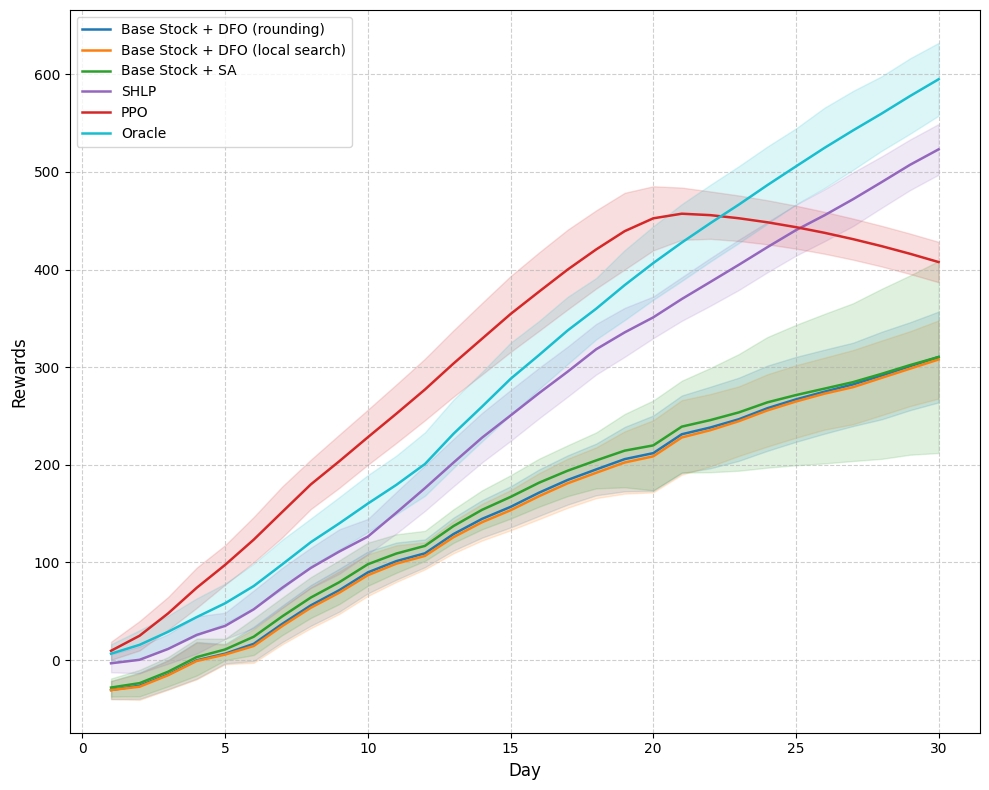

In [23]:
_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728', '#17becf']

algo_data = {
    'Base Stock + DFO (rounding)':     dfo_r_cr,
    'Base Stock + DFO (local search)': dfo_s_cr,
    'Base Stock + SA':                 sa_cr,
    'SHLP':                            shlp_cr,
    'PPO':                             ppo_cr,
    'Oracle':                          oracle_cr,
}

plot_cumulative_rewards(algo_data, _colors)

### 2. 各层级库存随时间变化

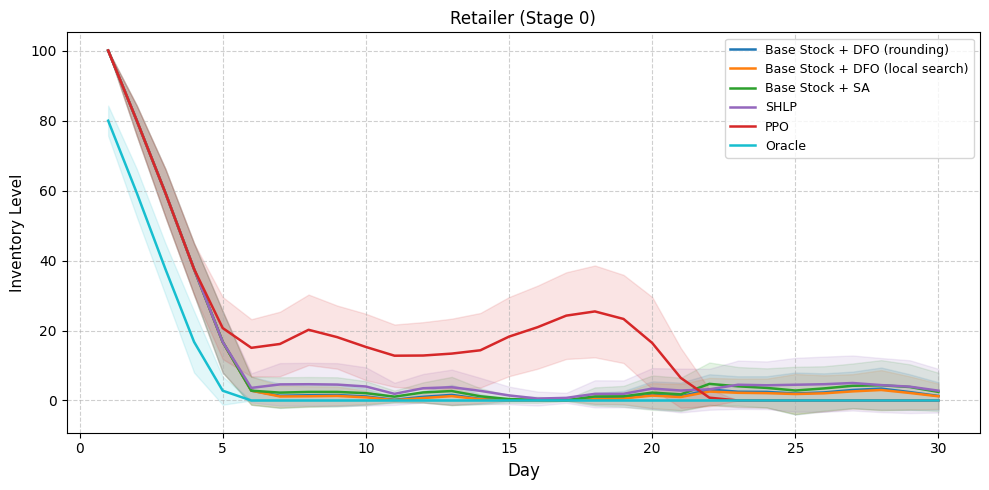

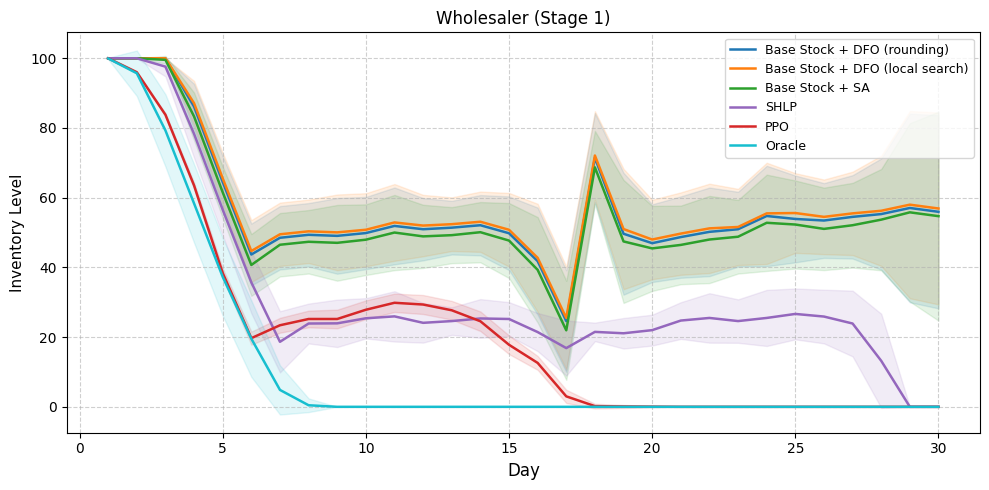

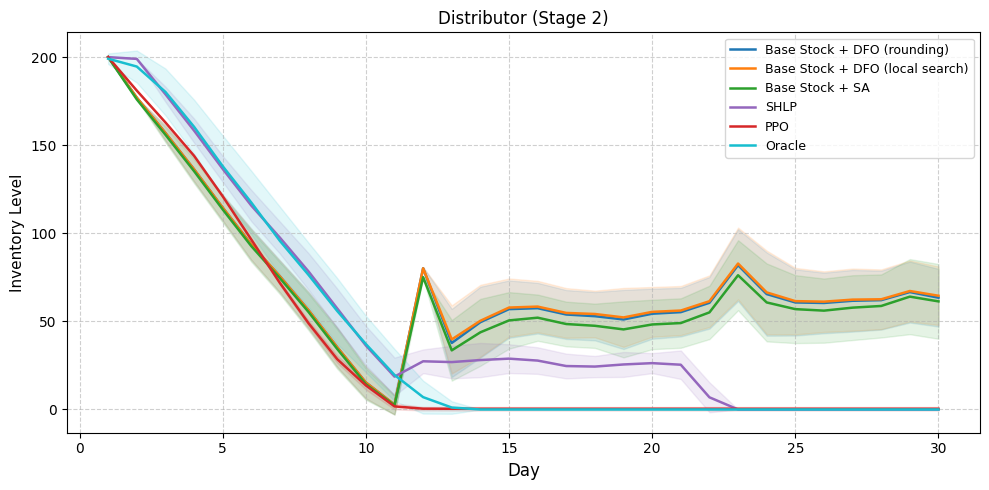

In [27]:
inv_data = {
    'Base Stock + DFO (rounding)':     dfo_r_inv,
    'Base Stock + DFO (local search)': dfo_s_inv,
    'Base Stock + SA':                 sa_inv,
    'SHLP':                            shlp_inv,
    'PPO':                             ppo_inv,
    'Oracle':                          oracle_inv,
}

plot_inventory_levels(inv_data, _colors)

### 3. 牛鞭效应：订货方差随供应链层级的放大

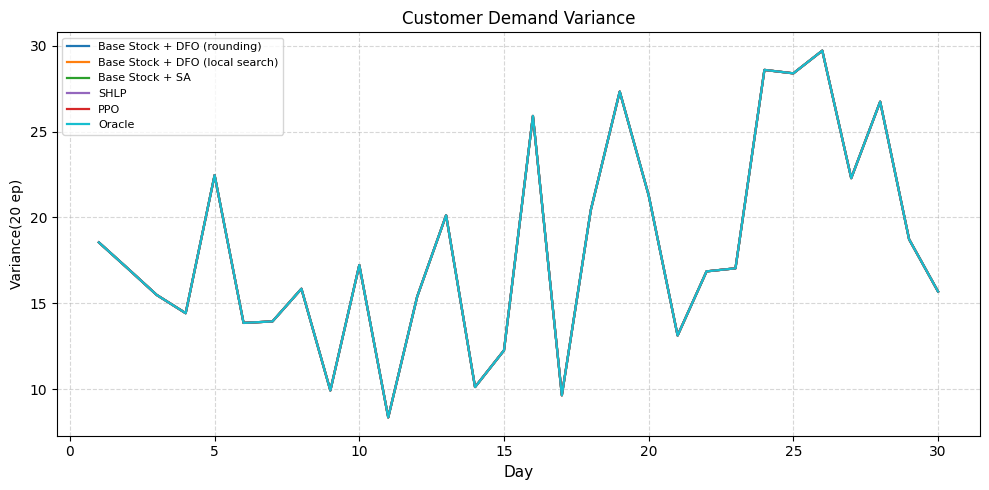

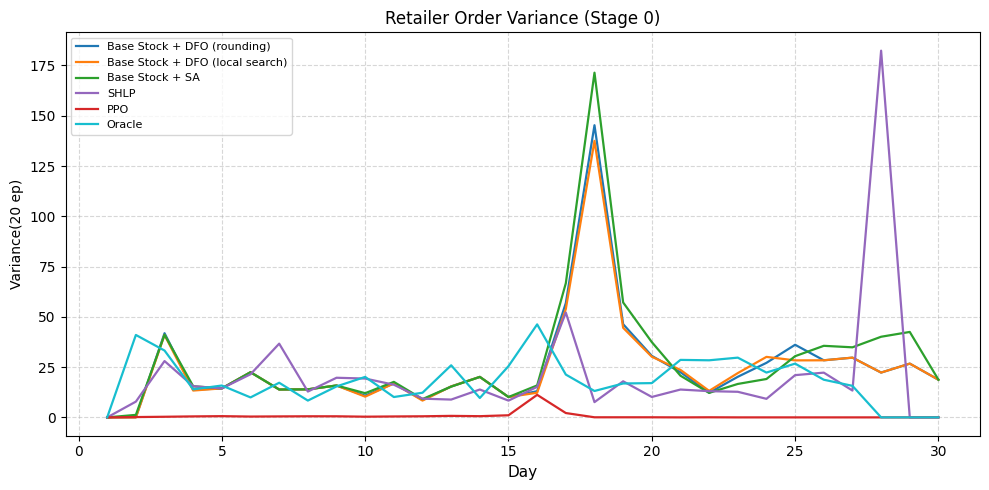

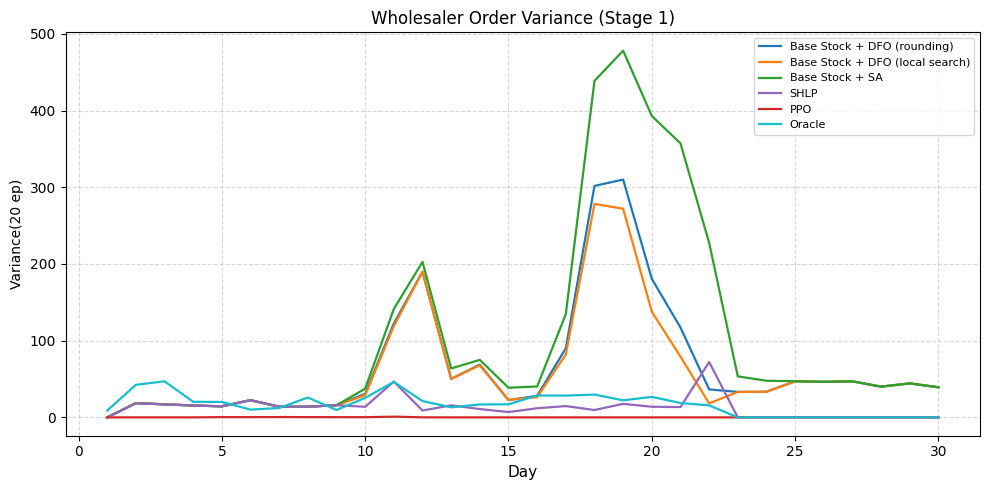

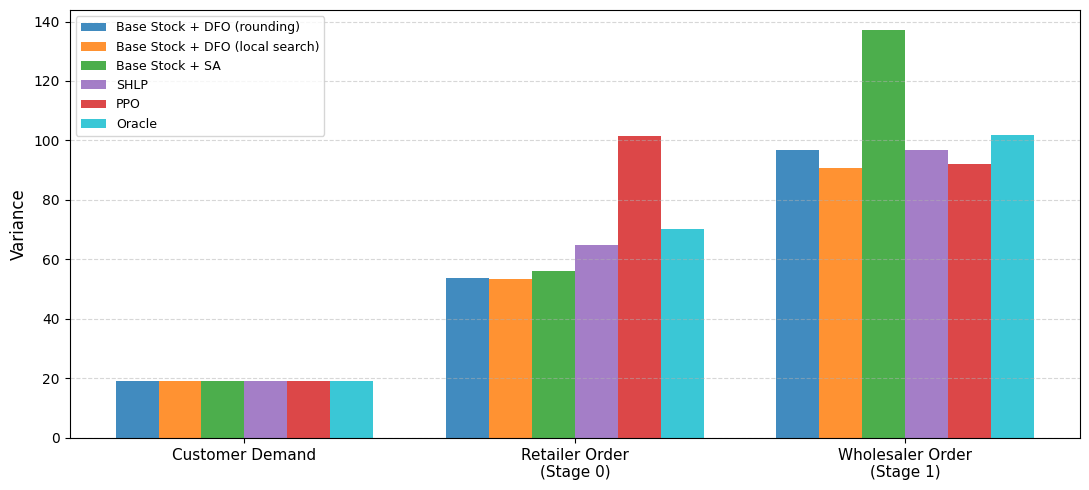


算法                                     需求方差        零售商订货方差        批发商订货方差       牛鞭比(批/需)
--------------------------------------------------------------------------------------
Base Stock + DFO (rounding)           19.22          53.74          96.87           5.04x
Base Stock + DFO (local search)       19.22          53.37          90.90           4.73x
Base Stock + SA                       19.22          56.20         137.02           7.13x
SHLP                                  19.22          64.76          96.75           5.03x
PPO                                   19.22         101.54          92.13           4.79x
Oracle                                19.22          70.26         101.97           5.30x


In [28]:
ord_data = {
    'Base Stock + DFO (rounding)':     (dfo_r_dem, dfo_r_ord),
    'Base Stock + DFO (local search)': (dfo_s_dem, dfo_s_ord),
    'Base Stock + SA':                 (sa_dem,    sa_ord),
    'SHLP':                            (shlp_dem,  shlp_ord),
    'PPO':                             (ppo_dem,   ppo_ord),
    'Oracle':                          (oracle_dem, oracle_ord),
}

plot_bullwhip(ord_data, _colors)


## 十、M5 真实数据对比实验

从 Kaggle M5 Forecasting 数据集中提取真实的沃尔玛商品周销量数据，在真实需求下对比各算法表现。

- 将周销量线性缩放到均值 ≈ 20，使其与环境的成本参数匹配（价格、持有成本、缺货惩罚、产能），保留真实数据的波动特征
- 使用滑动窗口，将提取的时间序列划分为多个以30周为一个周期的训练集，最后三十周划分为测试集，避免数据泄露

In [24]:
import pandas as pd

items_df = pd.read_csv("M5/weekly_sales_items_top105.csv") # 注意相对路径
grouped = items_df.groupby(["store_id", "item_id"])

target_mean = 20   # 与环境成本参数匹配
T_window = 30      # 窗口长度 = 环境周期数
stride = 10        # 滑动步长（训练窗口之间的间隔）

# 结构: m5_products[i] = { "label", "train": [seq1, seq2, ...], "test": seq }
m5_products = []

for (store, item), grp in grouped:
    ts = grp.sort_values("wm_yr_wk")["value"].values.astype(float)
    # 至少需要 2 * T_window 周（至少 1 个训练窗口 + 1 个测试窗口）
    if len(ts) < 2 * T_window:
        continue
    if ts.mean() < 1:
        continue

    # 测试集：最后 T_window 周
    test_raw = ts[-T_window:]
    if (test_raw == 0).sum() > 15:
        continue

    # 训练集：从头开始滑动窗口，不与测试集重叠
    train_end = len(ts) - T_window  # 训练数据截止位置
    train_seqs = []
    for start in range(0, train_end - T_window + 1, stride):
        window = ts[start: start + T_window]
        if (window == 0).sum() > 15:
            continue
        # 缩放
        scale = target_mean / (window.mean() + 1e-8)
        scaled = np.round(window * scale).astype(int)
        scaled = np.maximum(scaled, 0)
        train_seqs.append(scaled)

    if len(train_seqs) < 3:  # 至少 3 个训练窗口才有意义
        continue

    # 缩放测试集
    test_scale = target_mean / (test_raw.mean() + 1e-8)
    test_scaled = np.round(test_raw * test_scale).astype(int)
    test_scaled = np.maximum(test_scaled, 0)

    m5_products.append({
        "label": f"{store}/{item}",
        "train": train_seqs,
        "test": test_scaled,
    })

# 取前 20 个商品
m5_products = m5_products[:20]

# 汇总统计
print(f"共提取 {len(m5_products)} 个商品")
for i, p in enumerate(m5_products):
    train_means = [s.mean() for s in p['train']]
    print(f"  [{i:2d}] {p['label']:<30s} 训练窗口数={len(p['train']):>2d}  "
          f"训练均值={np.mean(train_means):.1f}  测试均值={p['test'].mean():.1f}")

共提取 20 个商品
  [ 0] CA_1/FOODS_1_004               训练窗口数=17  训练均值=20.0  测试均值=19.9
  [ 1] CA_1/FOODS_1_012               训练窗口数=16  训练均值=20.0  测试均值=20.1
  [ 2] CA_1/FOODS_1_018               训练窗口数=22  训练均值=20.0  测试均值=20.0
  [ 3] CA_1/FOODS_1_032               训练窗口数=18  训练均值=20.0  测试均值=20.2
  [ 4] CA_1/FOODS_1_043               训练窗口数=18  训练均值=20.0  测试均值=20.0
  [ 5] CA_1/FOODS_1_046               训练窗口数=22  训练均值=20.0  测试均值=20.0
  [ 6] CA_1/FOODS_1_082               训练窗口数=11  训练均值=20.0  测试均值=20.0
  [ 7] CA_1/FOODS_1_085               训练窗口数=22  训练均值=20.0  测试均值=19.9
  [ 8] CA_1/FOODS_1_096               训练窗口数=22  训练均值=20.0  测试均值=20.2
  [ 9] CA_1/FOODS_1_110               训练窗口数=18  训练均值=20.0  测试均值=19.9
  [10] CA_1/FOODS_1_161               训练窗口数=22  训练均值=20.0  测试均值=20.1
  [11] CA_1/FOODS_1_162               训练窗口数=15  训练均值=20.0  测试均值=20.0
  [12] CA_1/FOODS_1_173               训练窗口数=21  训练均值=20.0  测试均值=20.0
  [13] CA_1/FOODS_1_184               训练窗口数=18  训练均值=20.0  测试均值=20.1
  [14] CA_1/FOODS_1_218

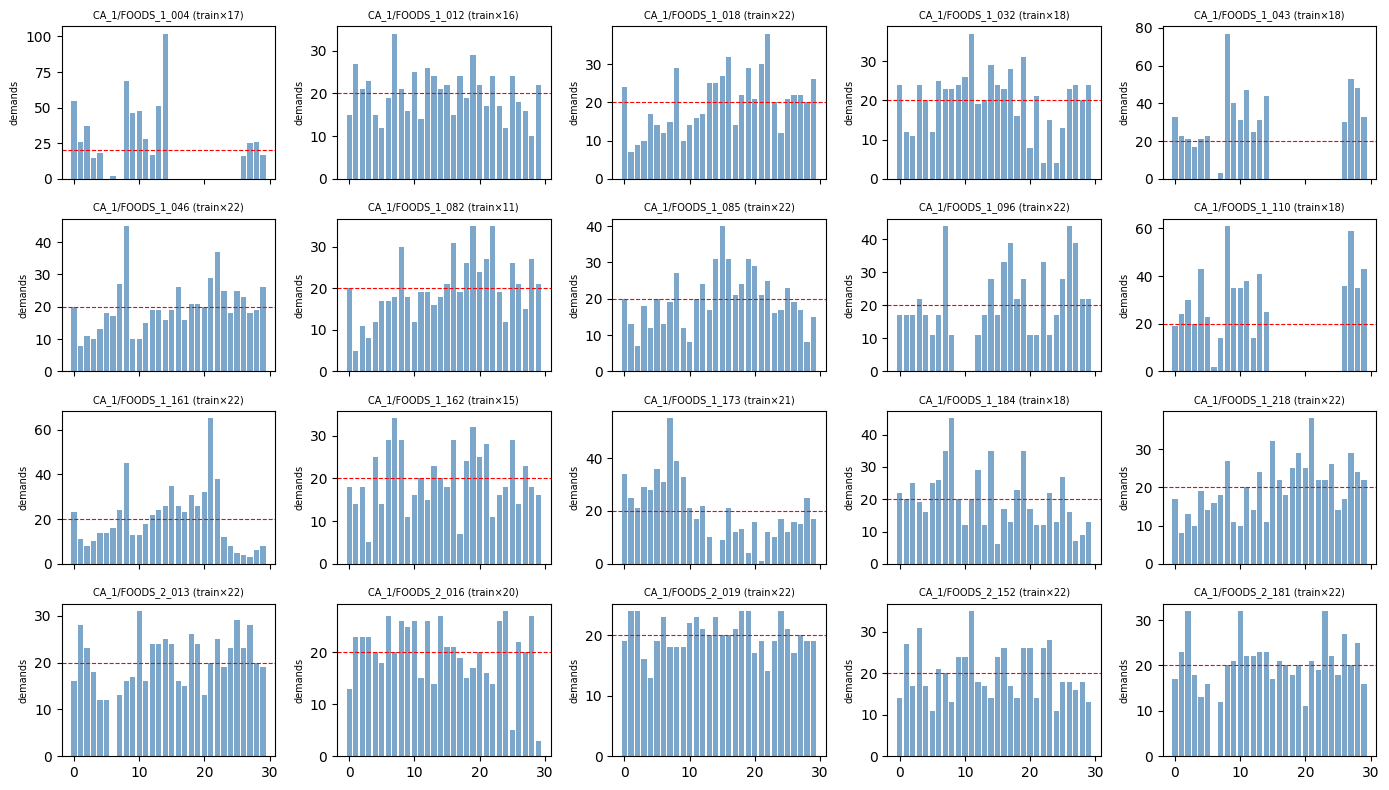

In [25]:
fig, axes = plt.subplots(4, 5, figsize=(14, 8), sharex=True)
for idx, ax in enumerate(axes.flat):
    if idx < len(m5_products):
        p = m5_products[idx]
        ax.bar(range(30), p["test"], color="steelblue", alpha=0.7)
        ax.axhline(y=20, color="red", ls="--", lw=0.8)
        ax.set_title(f"{p['label']} (train×{len(p['train'])})", fontsize=7)
        ax.set_ylabel("demands", fontsize=7)
plt.tight_layout()
plt.show()

In [26]:
# 对每个商品单独优化 Base Stock z，并在其测试序列上评估
def evaluate_z_m5(z, env, train_demands):
    """在训练需求集上评估 Base Stock 策略"""
    if np.any(z < 0):
        return 1e6
    profits = eval_fixed(env, lambda e: base_stock(e, z), train_demands)
    return -np.mean(profits)

def optimize_z_for_product(env, train_demands):
    """为单个商品在其训练集上优化 z：DFO + local search"""
    # 用该商品训练集统计量设定初始点
    mu = np.mean([d.mean() for d in train_demands])
    sigma = np.mean([d.std() for d in train_demands])
    L = env.L
    T_echelon = np.cumsum(L) + 1
    z0 = np.zeros(3)
    for m in range(3):
        z0[m] = mu * T_echelon[m] + 2 * sigma * np.sqrt(T_echelon[m])
    z0 = np.round(z0)

    # Powell DFO
    result = minimize(
        fun=evaluate_z_m5, x0=z0, args=(env, train_demands),
        method='Powell',
        options={'xtol': 1.0, 'ftol': 1.0, 'maxiter': 30, 'disp': False}
    )
    z_round = np.round(result.x).astype(int)

    # Local search
    offsets = [-1, 0, 1]
    neighborhood = list(itertools.product(offsets, repeat=3))
    best_z = z_round.copy()
    best_profit = -np.inf
    for offset in neighborhood:
        z_c = z_round + np.array(offset)
        z_c = np.maximum(z_c, 0)
        p = -evaluate_z_m5(z_c, env, train_demands)
        if p > best_profit:
            best_profit = p
            best_z = z_c
    return z0, z_round, best_z

env = ExactSupplyChainEnv()

# 对每个商品优化
print(f"开始为 {len(m5_products)} 个商品逐一优化 Base Stock z ...\n")
for i, prod in enumerate(m5_products):
    z0_i, z_round_i, z_local_i = optimize_z_for_product(env, prod["train"])
    prod["z0"] = z0_i
    prod["z_dfo_round"] = z_round_i
    prod["z_dfo_local"] = z_local_i
    
    # 训练集上的利润（验证 local ≥ round）
    train_profit_round = -evaluate_z_m5(z_round_i, env, prod["train"])
    train_profit_local = -evaluate_z_m5(z_local_i, env, prod["train"])
    
    print(f"  [{i:2d}] {prod['label']:<30s} "
          f"z0={z0_i.astype(int)}  "
          f"DFO={z_round_i}  Local={z_local_i}  "
          f"训练利润: round={train_profit_round:.1f} local={train_profit_local:.1f}")

开始为 20 个商品逐一优化 Base Stock z ...

  [ 0] CA_1/FOODS_1_004               z0=[122 244 472]  DFO=[ 21 228 513]  Local=[ 20 227 513]  训练利润: round=-166.2 local=-165.5
  [ 1] CA_1/FOODS_1_012               z0=[105 218 435]  DFO=[ 50 210 486]  Local=[ 51 211 487]  训练利润: round=129.1 local=131.3
  [ 2] CA_1/FOODS_1_018               z0=[107 221 439]  DFO=[ 47 213 472]  Local=[ 48 214 473]  训练利润: round=164.7 local=166.4
  [ 3] CA_1/FOODS_1_032               z0=[123 245 474]  DFO=[  2 224 584]  Local=[  1 223 583]  训练利润: round=-252.2 local=-248.4
  [ 4] CA_1/FOODS_1_043               z0=[120 241 468]  DFO=[ 28 226 544]  Local=[ 27 225 543]  训练利润: round=-126.3 local=-125.3
  [ 5] CA_1/FOODS_1_046               z0=[115 232 456]  DFO=[ 67 229 487]  Local=[ 68 230 488]  训练利润: round=197.8 local=198.2
  [ 6] CA_1/FOODS_1_082               z0=[174 321 585]  DFO=[  1 263 573]  Local=[  0 262 573]  训练利润: round=-4311.2 local=-4249.6
  [ 7] CA_1/FOODS_1_085               z0=[109 224 444]  DFO=[ 31 215 489]  

In [27]:
env = ExactSupplyChainEnv()

# 每个商品用各自优化的 z 在自己的测试序列上评估
print("正在逐商品评估 ...")
m5_oracle = []
m5_dfo_round = []
m5_dfo_search = []
m5_shlp_list = []
m5_ppo_list = []

for i, prod in enumerate(m5_products):
    test_seq = [prod["test"]]  # eval_fixed 接受列表
    
    # Oracle
    m5_oracle.append(oracle(env, prod["test"]))
    
    # DFO rounding（每商品各自的 z）
    m5_dfo_round.append(eval_fixed(env, lambda e, z=prod["z_dfo_round"]: base_stock(e, z), test_seq)[0])
    
    # DFO local search（每商品各自的 z）
    m5_dfo_search.append(eval_fixed(env, lambda e, z=prod["z_dfo_local"]: base_stock(e, z), test_seq)[0])
    
    # SHLP（使用该商品训练集的均值）
    mu_i = np.mean([d.mean() for d in prod["train"]])
    m5_shlp_list.append(eval_shlp(env, mu_i, test_seq)[0])
    
    # PPO
    m5_ppo_list.append(eval_ppo(_ppo_model, _ppo_vec, test_seq)[0])

# 汇总结果
results = {
    "Oracle":                      m5_oracle,
    "Base Stock + DFO (rounding)": m5_dfo_round,
    "Base Stock + DFO (local)":    m5_dfo_search,
    "SHLP":                        m5_shlp_list,
    "PPO":                         m5_ppo_list,
}

print(f"\n{'算法':<32} {'平均利润':>10} {'标准差':>10} {'占Oracle%':>10}")
print("-" * 66)
for name, vals in results.items():
    avg, std = np.mean(vals), np.std(vals)
    pct = avg / np.mean(m5_oracle) * 100
    print(f"{name:<32} {avg:>10.2f} {std:>10.2f} {pct:>9.1f}%")

# 逐商品明细
print(f"\n{'商品':<30s} {'Oracle':>8} {'DFO-R':>8} {'DFO-L':>8} {'SHLP':>8} {'PPO':>8}")
print("-" * 74)
for i, prod in enumerate(m5_products):
    print(f"{prod['label']:<30s} "
          f"{m5_oracle[i]:>8.1f} {m5_dfo_round[i]:>8.1f} {m5_dfo_search[i]:>8.1f} "
          f"{m5_shlp_list[i]:>8.1f} {m5_ppo_list[i]:>8.1f}")

正在逐商品评估 ...

算法                                     平均利润        标准差   占Oracle%
------------------------------------------------------------------
Oracle                               582.68      66.47     100.0%
Base Stock + DFO (rounding)         -174.90     644.68     -30.0%
Base Stock + DFO (local)            -172.04     634.76     -29.5%
SHLP                                 454.21      57.36      78.0%
PPO                                  362.81      51.28      62.3%

商品                               Oracle    DFO-R    DFO-L     SHLP      PPO
--------------------------------------------------------------------------
CA_1/FOODS_1_004                  681.5  -2623.7  -2575.3    474.8    367.4
CA_1/FOODS_1_012                  604.0    244.4    247.6    542.7    413.6
CA_1/FOODS_1_018                  495.0    123.7    126.5    388.5    282.3
CA_1/FOODS_1_032                  602.3   -133.5   -135.4    498.1    401.6
CA_1/FOODS_1_043                  657.5   -533.2   -530.1    392.9  

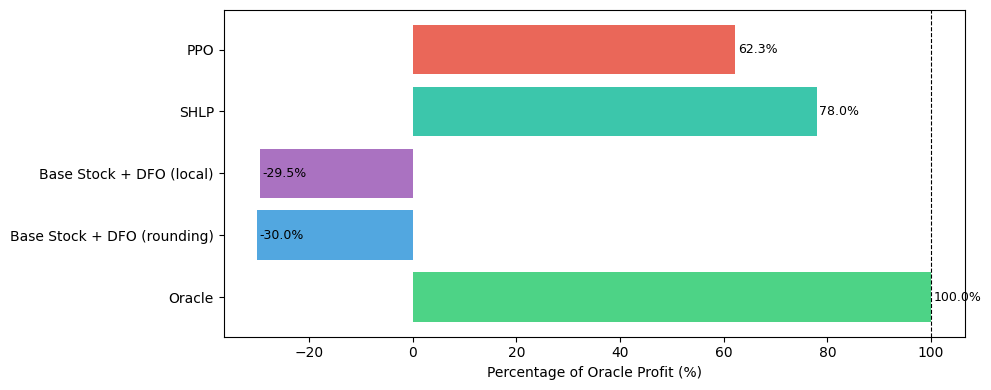

In [96]:
algo_names = list(results.keys())
m5_avgs = [np.mean(v) for v in results.values()]

# 占 Oracle 百分比
fig, ax = plt.subplots(figsize=(10, 4))
oracle_avg = np.mean(m5_oracle)
ratios = [(np.mean(v) / oracle_avg * 100) for v in results.values()]
colors = ["#2ecc71", "#3498db", "#9b59b6", "#1abc9c", "#e74c3c"]
bars = ax.barh(algo_names, ratios, color=colors[:len(algo_names)], alpha=0.85)
ax.set_xlabel("Percentage of Oracle Profit (%)")
ax.axvline(x=100, color="black", ls="--", lw=0.8)
for bar, r in zip(bars, ratios):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{r:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

- 画出某个商品训练集和测试集需求分布的差异情况，探究Base Stock策略失效的原因

In [115]:
def plot_train_test_distribution(prod, idx=None):
    """
    对比单个商品训练集与测试集的需求分布，说明 Base Stock 失效原因
    """
    train_all = np.concatenate(prod["train"])
    test_all  = prod["test"]
    label = prod["label"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    # ---- 子图1: 训练 vs 测试 时序对比 ----
    ax = axes[0]
    # 画所有训练窗口（浅色叠加）
    for i, seq in enumerate(prod["train"]):
        ax.plot(seq, color="steelblue", alpha=0.15, lw=0.8)
    # 训练集均值轨迹
    train_mean_seq = np.mean(prod["train"], axis=0)
    ax.plot(train_mean_seq, color="steelblue", lw=2, label=f"Train mean (n={len(prod['train'])})")
    ax.plot(test_all, color="darkorange", lw=2, label="Test")
    ax.axhline(y=np.mean(train_all), color="steelblue", ls="--", lw=0.8, alpha=0.6)
    ax.axhline(y=np.mean(test_all), color="darkorange", ls="--", lw=0.8, alpha=0.6)
    ax.set_xlabel("Period")
    ax.set_ylabel("Demand")
    ax.set_title("Train vs Test")
    ax.legend(fontsize=8)

    # ---- 子图2: 直方图对比 ----
    ax = axes[1]
    bins = np.arange(0, max(train_all.max(), test_all.max()) + 3, 2)
    ax.hist(train_all, bins=bins, alpha=0.6, color="steelblue", density=True, label=f"Train (μ={train_all.mean():.1f}, σ={train_all.std():.1f})")
    ax.hist(test_all,  bins=bins, alpha=0.6, color="darkorange", density=True, label=f"Test  (μ={test_all.mean():.1f}, σ={test_all.std():.1f})")
    ax.set_xlabel("Demand")
    ax.set_ylabel("Density")
    ax.set_title("Demand distribution")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # 文字总结
    shift = test_all.mean() - train_all.mean()
    print(f"  均值偏移: {shift:+.1f} ({shift/train_all.mean()*100:+.1f}%)")
    print(f"  方差比:   {test_all.std():.1f} / {train_all.std():.1f} = {test_all.std()/train_all.std():.2f}")
    if abs(shift / train_all.mean()) > 0.15 or test_all.std() / train_all.std() > 1.5:
        print("训练/测试分布差异较大")

- 以某个Base Stock策略表现较好/较差的商品作为代表

In [101]:
# 选取某个商品作为可视化代表
def test(rep):
    env = ExactSupplyChainEnv()
    rep_test   = [rep["test"]]          # 单条测试序列
    rep_mu     = np.mean([d.mean() for d in rep["train"]])
    rep_label  = rep["label"]
    print(f"可视化代表商品: {rep_label}  z_round={rep['z_dfo_round']}  z_local={rep['z_dfo_local']}")

    print("收集 M5 Base Stock + DFO (rounding) 数据...")
    m5_dfo_r_cr, m5_dfo_r_inv, m5_dfo_r_ord, m5_dfo_r_dem = collect_step_data(
        env, lambda e, z=rep["z_dfo_round"]: base_stock(e, z), rep_test)

    print("收集 M5 Base Stock + DFO (local search) 数据...")
    m5_dfo_s_cr, m5_dfo_s_inv, m5_dfo_s_ord, m5_dfo_s_dem = collect_step_data(
        env, lambda e, z=rep["z_dfo_local"]: base_stock(e, z), rep_test)

    print("收集 M5 SHLP 数据...")
    m5_shlp_cr, m5_shlp_inv, m5_shlp_ord, m5_shlp_dem = collect_step_data_shlp(env, rep_mu, rep_test)

    print("收集 M5 PPO 数据...")
    m5_ppo_cr, m5_ppo_inv, m5_ppo_ord, m5_ppo_dem = collect_step_data_ppo(_ppo_model, _ppo_vec, rep_test)

    print("收集 M5 Oracle 数据...")
    m5_oracle_cr, m5_oracle_inv, m5_oracle_ord, m5_oracle_dem = collect_step_data_oracle(env, rep_test)

    print(f"\n绘制 M5 累积奖励曲线 ({rep_label}) ...")
    m5_algo_data = {
        'Base Stock + DFO (rounding)':     m5_dfo_r_cr,
        'Base Stock + DFO (local search)': m5_dfo_s_cr,
        'SHLP':                            m5_shlp_cr,
        'PPO':                             m5_ppo_cr,
        'Oracle':                          m5_oracle_cr,
    }
    plot_cumulative_rewards(m5_algo_data, _colors)

    print("绘制 M5 各层级库存曲线...")
    m5_inv_data = {
        'Base Stock + DFO (rounding)':     m5_dfo_r_inv,
        'Base Stock + DFO (local search)': m5_dfo_s_inv,
        'SHLP':                            m5_shlp_inv,
        'PPO':                             m5_ppo_inv,
        'Oracle':                          m5_oracle_inv,
    }
    plot_inventory_levels(m5_inv_data, _colors)

可视化代表商品: CA_1/FOODS_1_046  z_round=[ 67 229 487]  z_local=[ 68 230 488]
收集 M5 Base Stock + DFO (rounding) 数据...
收集 M5 Base Stock + DFO (local search) 数据...
收集 M5 SHLP 数据...
收集 M5 PPO 数据...
收集 M5 Oracle 数据...

绘制 M5 累积奖励曲线 (CA_1/FOODS_1_046) ...


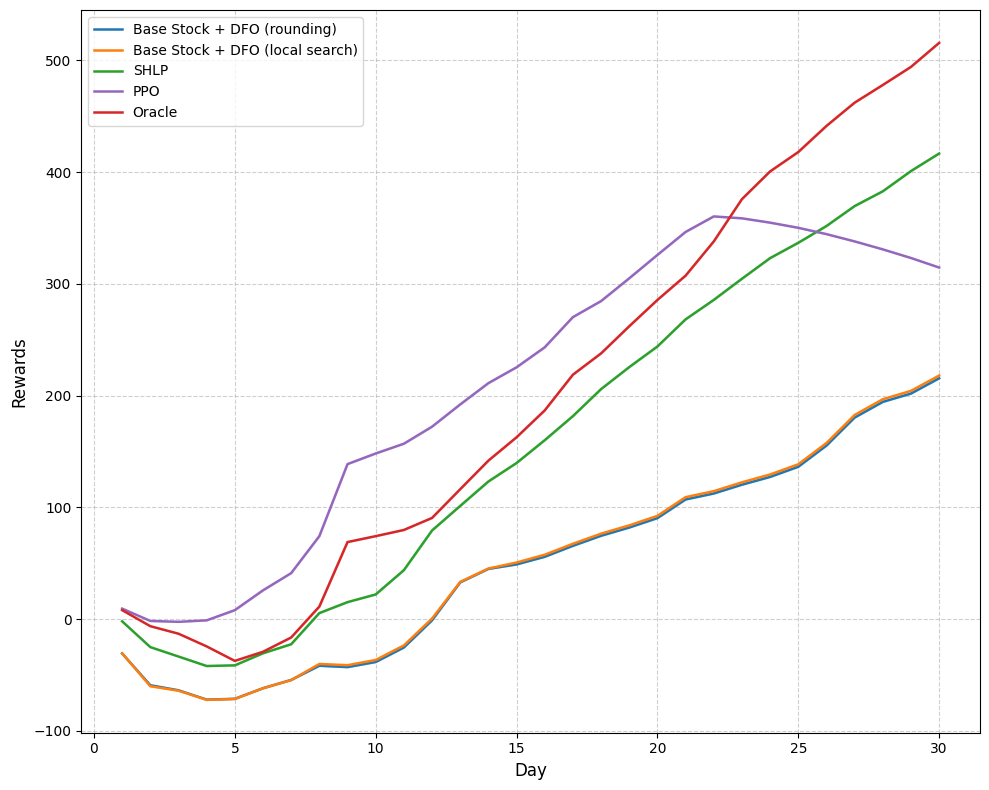

绘制 M5 各层级库存曲线...


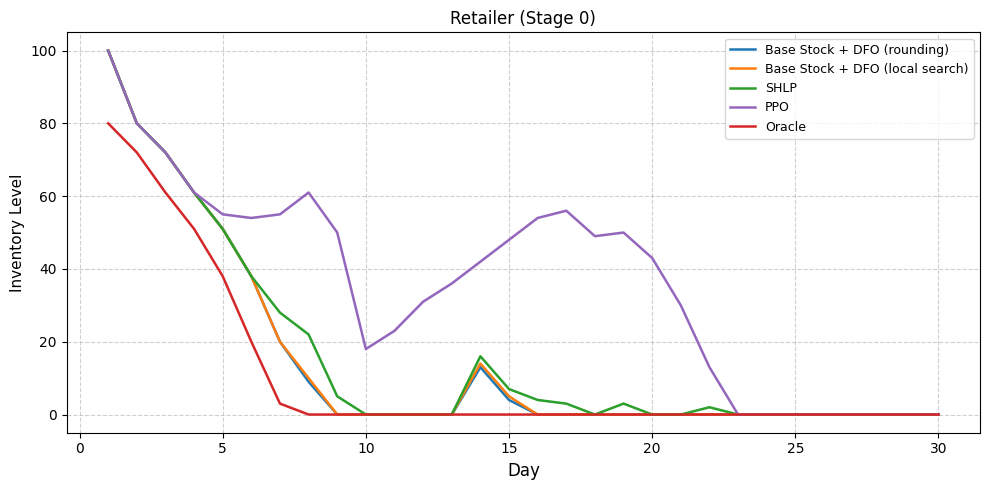

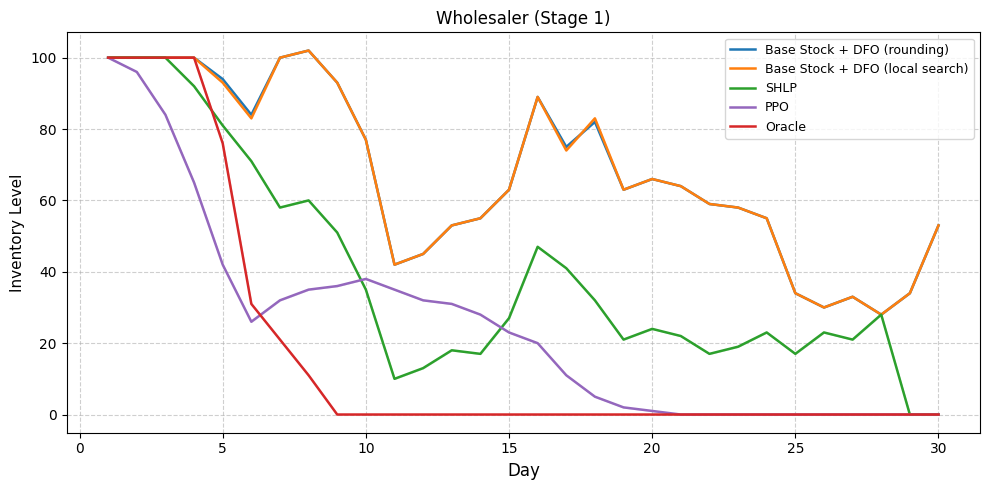

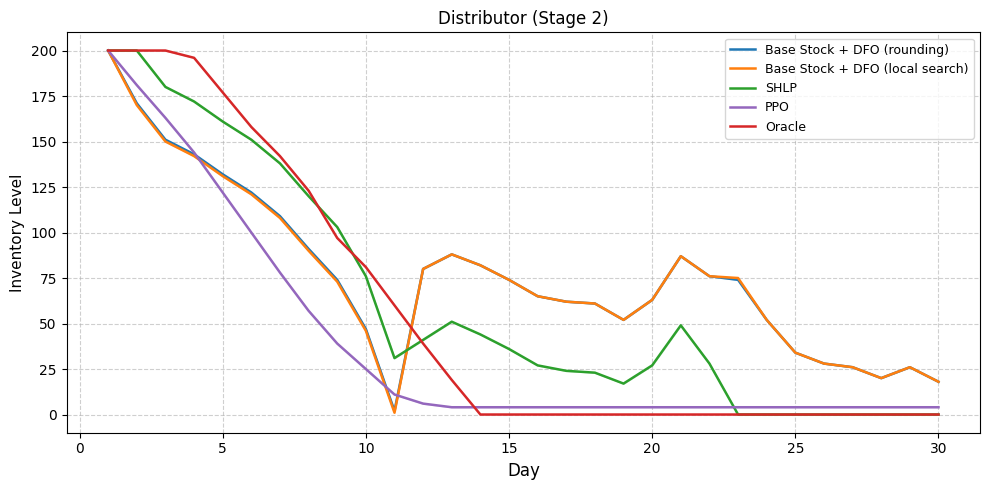

In [116]:
rep1= m5_products[5] # base stock策略表现较好的商品
test(rep1)

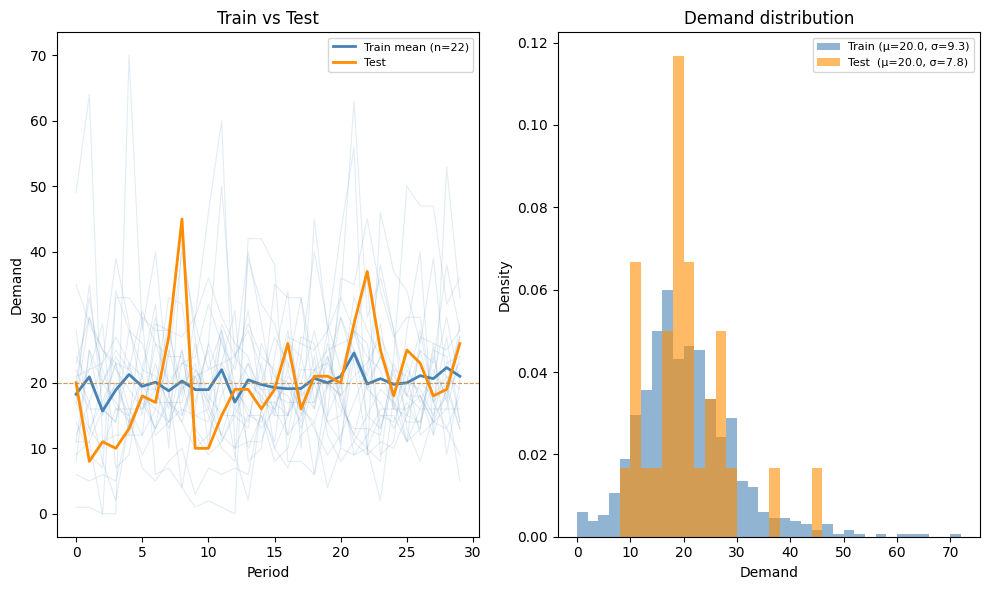

  均值偏移: +0.0 (+0.2%)
  方差比:   7.8 / 9.3 = 0.84


In [114]:
plot_train_test_distribution(m5_products[5])

可视化代表商品: CA_1/FOODS_1_043  z_round=[ 28 226 544]  z_local=[ 27 225 543]
收集 M5 Base Stock + DFO (rounding) 数据...
收集 M5 Base Stock + DFO (local search) 数据...
收集 M5 SHLP 数据...
收集 M5 PPO 数据...
收集 M5 Oracle 数据...

绘制 M5 累积奖励曲线 (CA_1/FOODS_1_043) ...


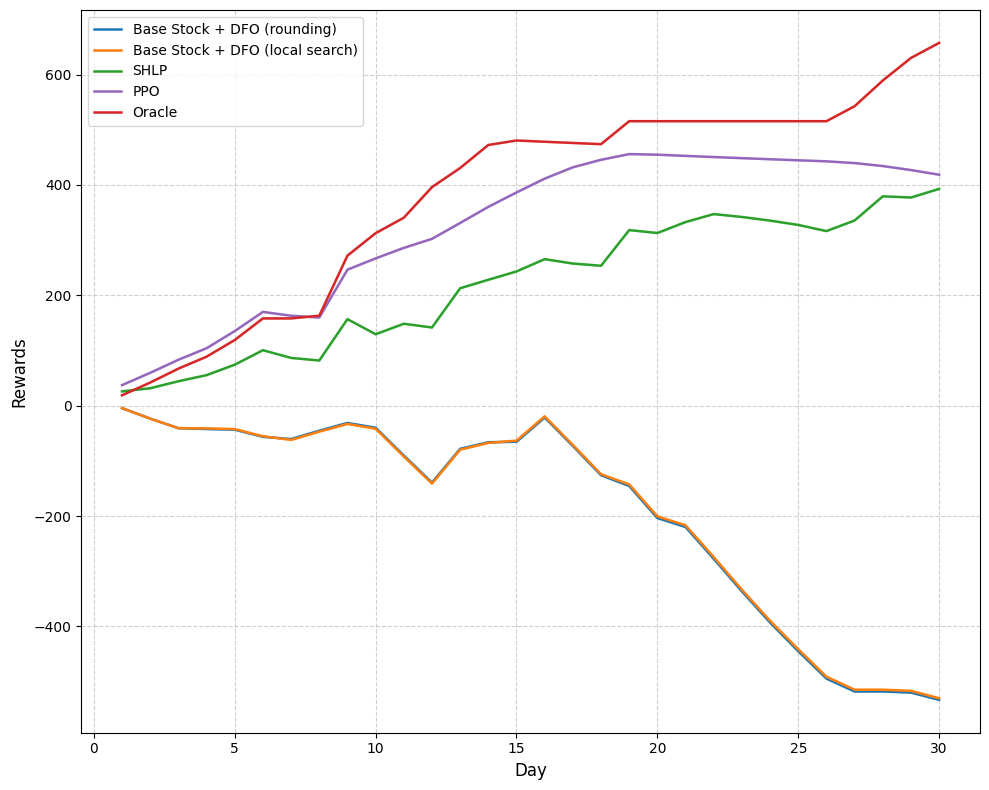

绘制 M5 各层级库存曲线...


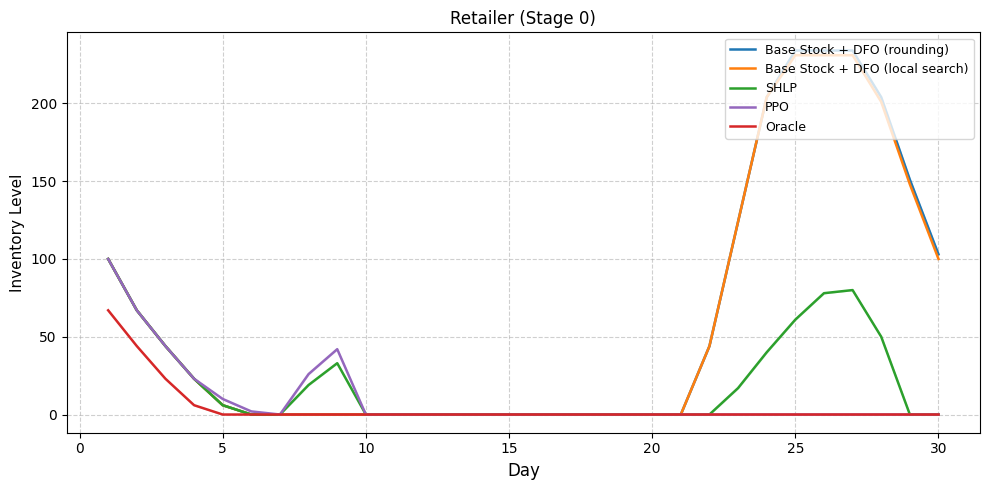

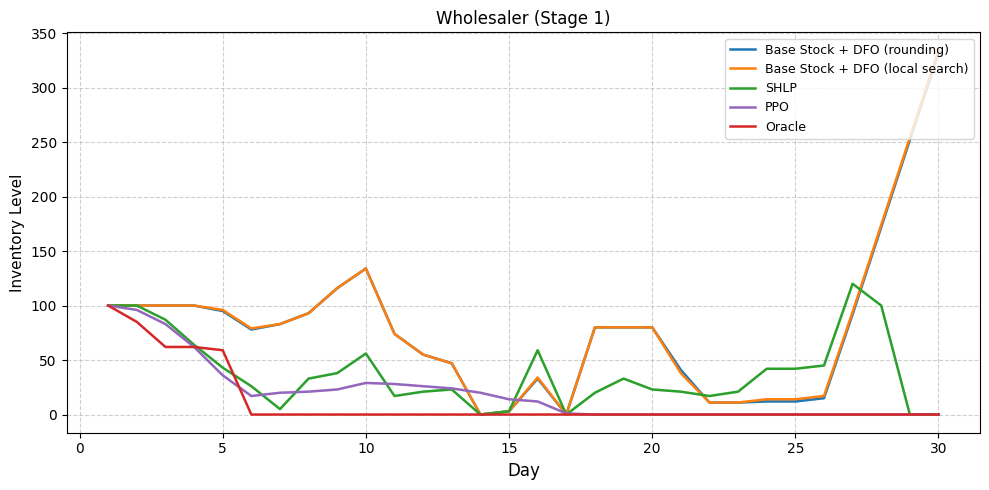

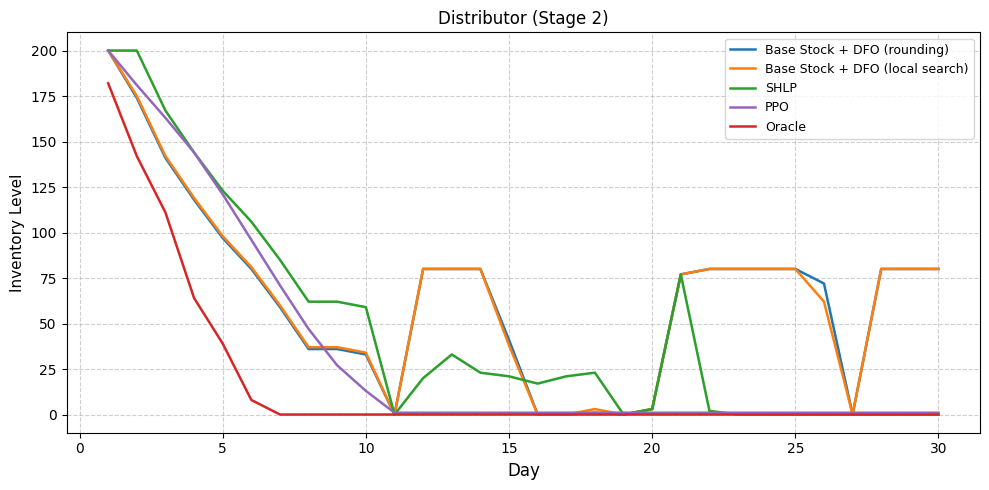

In [117]:
rep2= m5_products[4] # base stock策略表现较差的商品
test(rep2)

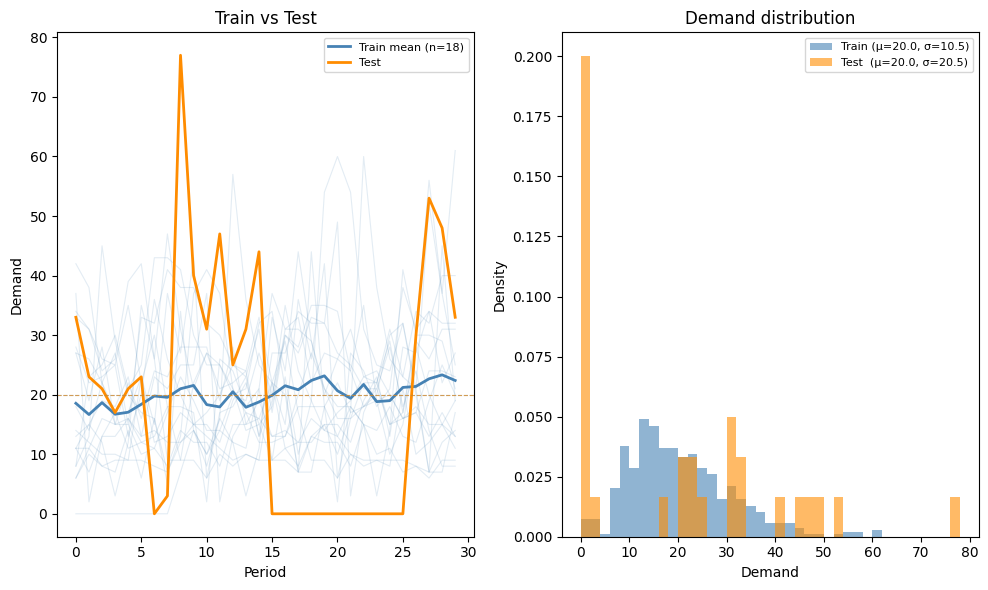

  均值偏移: +0.0 (+0.0%)
  方差比:   20.5 / 10.5 = 1.95
训练/测试分布差异较大


In [118]:
plot_train_test_distribution(m5_products[4])

## 十一、PPO 改进

### 问题分析

由于利润通过 $\alpha^n$ 折扣，且第 30 天之后没有任何收益，智能体发现**在周期末持有库存只会产生成本而无未来销售收入**，因此在最后几天停止补货、将库存清零。

这在有限周期中是最优的，但在实际运营中供应链不会终止。

### 改进方案

在环境的最后一步（`done=True`）为期末剩余库存添加 **残值（salvage value）** 奖励：

$$r_{T} = r_{T}^{\text{原始}} + \alpha^{T} \sum_{m=0}^{M-2} v_m \cdot I_{T+1}^m$$

其中 $v_m$ 为各层级库存的单位残值，设为各层级的采购成本 $r_m$（即库存至少值其采购价）。这样 PPO 就不会在周期末端主动清空库存（事实上仍会清空，但有进步）。

In [28]:
class SB3SupplyChainEnvV2(ExactSupplyChainEnv, gym.Env):
    """
    改进版 PPO 环境：在 episode 最后一步添加期末残值奖励，
    避免智能体在周期末端过早清空库存。
    """
    def __init__(self):
        super().__init__()
        self.action_space = spaces.Box(
            low=np.zeros(self.num_stages - 1, dtype=np.float32),
            high=self.c.astype(np.float32),
            dtype=np.float32
        )
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(self.state_dim,), dtype=np.float32
        )
        # 期末残值：各层级库存按采购成本估值
        self.salvage_value = self.r[:self.num_stages - 1]  # [1.5, 1.0, 0.75]

    def step(self, action):
        discrete_action = np.round(action).astype(int)
        obs, reward, done, info = super().step(discrete_action)

        # 在最后一步添加期末残值
        if done:
            terminal_inventory = self.I[self.current_step, :]  # 期末库存
            salvage = self.alpha ** (self.current_step - 1) * np.sum(
                self.salvage_value * terminal_inventory
            )
            reward += salvage

        truncated = False
        return np.array(obs, dtype=np.float32), float(reward), bool(done), truncated, info

    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
        obs = super().reset()
        return np.array(obs, dtype=np.float32), {}


print(f"残值系数: {SB3SupplyChainEnvV2().salvage_value}")
print(f"初始库存: {SB3SupplyChainEnvV2().I0}")
print(f"最大残值奖励 ≈ {0.97**29 * np.sum(np.array([1.5, 1.0, 0.75]) * np.array([100, 100, 200])):.2f}")

残值系数: [1.5  1.   0.75]
初始库存: [100 100 200]
最大残值奖励 ≈ 165.36


In [ ]:
vec_env_v2 = DummyVecEnv([lambda: Monitor(SB3SupplyChainEnvV2())])
vec_env_v2 = VecNormalize(vec_env_v2, norm_obs=True, norm_reward=True, clip_obs=1000.0, gamma=0.97)

model_v2 = PPO(
    "MlpPolicy",
    vec_env_v2,
    verbose=1,
    learning_rate=lambda progress: 3e-4 * (0.1 + 0.9 * progress),
    n_steps=2048,
    batch_size=512,
    n_epochs=10,
    gamma=0.97,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.05,
    vf_coef=0.5,
    seed=42,
    policy_kwargs=dict(net_arch=[256, 256]),
    tensorboard_log="./ppo_tensorboard/"
)

print("--- 开始训练 PPO V2 ---")
model_v2.learn(total_timesteps=1000000)
print("\n--- 训练完成 ---")

SAVE_DIR = r".\ppo_supply_chain"
os.makedirs(SAVE_DIR, exist_ok=True)
model_v2.save(os.path.join(SAVE_DIR, "model_v2"))
vec_env_v2.save(os.path.join(SAVE_DIR, "vec_normalize_v2.pkl"))
print(f"模型已保存至: {SAVE_DIR}/model_v2.zip")

Using cpu device
--- 开始训练 PPO V2（含期末残值） ---
Logging to ./ppo_tensorboard/PPO_4
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 30       |
|    ep_rew_mean     | -464     |
| time/              |          |
|    fps             | 1311     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 30          |
|    ep_rew_mean          | -465        |
| time/                   |             |
|    fps                  | 1256        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011150779 |
|    clip_fraction        | 0.0723      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.27  

In [ ]:
SAVE_DIR = r".\ppo_supply_chain"
_ppo_v2_vec = DummyVecEnv([lambda: SB3SupplyChainEnv()])  # 评估时用原始环境
_ppo_v2_vec = VecNormalize.load(os.path.join(SAVE_DIR, "vec_normalize_v2.pkl"), _ppo_v2_vec)
_ppo_v2_vec.training = False
_ppo_v2_vec.norm_reward = False
_ppo_v2_model = PPO.load(os.path.join(SAVE_DIR, "model_v2"), env=_ppo_v2_vec)

np.random.seed(42)
eval_seed_env = DummyVecEnv([lambda: SB3SupplyChainEnv()])
eval_seed_env = VecNormalize(eval_seed_env, norm_obs=True, norm_reward=False, clip_obs=1000.0, gamma=0.97, training=False)
eval_seed_env.obs_rms = _ppo_v2_vec.obs_rms
mean_reward_v2, std_reward_v2 = evaluate_policy(_ppo_v2_model, eval_seed_env, n_eval_episodes=100, deterministic=True)
print(f"PPO V2 (含残值训练) 100 次测试平均折现总利润: {mean_reward_v2:.2f} +/- {std_reward_v2:.2f}")
print(f"原始 PPO 对比:                              {mean_reward:.2f} +/- {std_reward:.2f}")

np.random.seed(45)
eval_env = SB3SupplyChainEnv()
obs, _ = eval_env.reset(seed=450)
obs_normalized = _ppo_v2_vec.normalize_obs(obs)
done = False
truncated = False
total_profit = 0
print(f"\n{'天数':<5} | {'需求':<5} | {'零销量':<6} | {'动作(R, W, D)':<15} | {'期末库存':<15} | {'本日利润':<8}")
print("-" * 70)
while not (done or truncated):
    action, _ = _ppo_v2_model.predict(obs_normalized, deterministic=True)
    obs, reward, done, truncated, info = eval_env.step(action)
    obs_normalized = _ppo_v2_vec.normalize_obs(obs)
    total_profit += reward
    print(f"{eval_env.current_step:<6} | {info['demand']:<7} | {info['sales'][0]:<8.0f} | "
          f"{str(np.round(action).astype(int)):<17} | "
          f"{str(eval_env.I[eval_env.current_step, :].astype(int)):<17} | {reward:<8.2f}")
print("-" * 70)
print(f"PPO V2 单次演示总折现利润: {total_profit:.2f}")

e:\Miniconda3\envs\rl\lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


PPO V2 (含残值训练) 100 次测试平均折现总利润: 407.44 +/- 21.89
原始 PPO 对比:                              404.27 +/- 22.05

天数    | 需求    | 零销量    | 动作(R, W, D)     | 期末库存            | 本日利润    
----------------------------------------------------------------------
1      | 24      | 24       | [ 5 18  3]        | [ 76  95 182]     | 16.50   
2      | 24      | 24       | [12 18  1]        | [ 52  83 164]     | 22.50   
3      | 18      | 18       | [24 22  0]        | [ 34  59 142]     | 16.84   
4      | 28      | 28       | [20 25  0]        | [ 11  39 117]     | 40.71   
5      | 15      | 15       | [19 22  0]        | [ 8 20 95]        | 19.52   
6      | 28      | 28       | [22 23  0]        | [ 4 18 72]        | 42.81   
7      | 21      | 21       | [15 23  0]        | [ 3 19 49]        | 30.99   
8      | 19      | 19       | [18 25  0]        | [ 3 23 24]        | 27.51   
9      | 18      | 18       | [20 17  0]        | [ 5 28  7]        | 25.16   
10     | 20      | 20       | [25 14  0]  

In [29]:
# PPO
SAVE_DIR = r".\ppo_supply_chain"
_ppo_vec = DummyVecEnv([lambda: SB3SupplyChainEnv()])
_ppo_vec = VecNormalize.load(os.path.join(SAVE_DIR, "vec_normalize_v2.pkl"), _ppo_vec)
_ppo_vec.training = False
_ppo_vec.norm_reward = False
_ppo_model = PPO.load(os.path.join(SAVE_DIR, "model_v2"), env=_ppo_vec)

ppo_profits = eval_ppo(_ppo_model, _ppo_vec, demands)
avg_ppo = np.mean(ppo_profits)
std_ppo = np.std(ppo_profits)
print(f"PPO 平均折现总利润: {avg_ppo:.2f} +/- {std_ppo:.2f}")
m5_ppo = eval_ppo(_ppo_model, _ppo_vec, test_seq)
avg, std = np.mean(m5_ppo), np.std(m5_ppo)
pct = avg / np.mean(m5_oracle) * 100
print(f"改进后的PPO在真实数据集上：{avg:>10.2f} {std:>10.2f} {pct:>9.1f}%")

PPO 平均折现总利润: 410.72 +/- 20.02
改进后的PPO在真实数据集上：    387.78       0.00      66.6%
